In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_pinball_loss
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data
from data.model_features import (
    get_grouped_model_feature_columns,
    split_feature_types,
)
from models.gradient_boosting import (
    build_gradient_boosting_pipeline,
    train_gradient_boosting,
    predict_gradient_boosting,
    get_transformed_predictions,
    get_feature_importances,
    transform_target,
)
from evaluation.model_evaluation import (
    run_regression_evaluation,
    plot_actual_vs_predicted,
    plot_residual_distribution,
    plot_tail_comparison,
    plot_grouped_actual_vs_predicted,
)
from evaluation.shap_analysis import (
    run_shap_analysis,
    plot_shap_bar,
    plot_shap_beeswarm,
    plot_shap_waterfall,
    plot_shap_importance_dataframe,
)
from export.report_exports import (
    create_report_output_dirs,
    export_report_table,
    save_report_figure,
    set_report_plot_style,
)

NOTEBOOK_NAME = "06_gradient_boosting_experiments"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

sns.set_theme(style="whitegrid")
set_report_plot_style()

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = f"log1p_{target}"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

print("Shape:", df.shape)
display(df.head())

data_summary_table = data_summary(df)
display(data_summary_table)

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_data_summary.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_data_summary.csv')

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

BASE_GB_PARAMS = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 3,
    "subsample": 1.0,
}

REGULARISED_GB_PARAMS = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 2,
    "subsample": 0.80,
    "gradient_boosting_params": {
        "min_samples_leaf": 50,
    },
}

EXPERIMENT_CONFIGS = [
    {
        "name": "baseline_grouped",
        "feature_mode": "grouped",
        "loss": "squared_error",
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "regularised_grouped",
        "feature_mode": "grouped",
        "loss": "squared_error",
        **REGULARISED_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "raw_health_features",
        "feature_mode": "raw_health_features",
        "loss": "squared_error",
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "grouped_without_days_hospitalized",
        "feature_mode": "grouped_without_days_hospitalized",
        "loss": "squared_error",
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "grouped_with_interaction",
        "feature_mode": "grouped",
        "add_interaction": True,
        "loss": "squared_error",
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "absolute_error_robust",
        "feature_mode": "grouped",
        "loss": "absolute_error",
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "huber_robust",
        "feature_mode": "grouped",
        "loss": "huber",
        "quantile_alpha": 0.90,
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "tail_weighted_squared_error",
        "feature_mode": "grouped",
        "loss": "squared_error",
        **BASE_GB_PARAMS,
        "weighted": True,
        "p95_weight": 5.0,
        "p99_weight": 10.0,
    },
    {
        "name": "quantile_p90",
        "feature_mode": "grouped",
        "loss": "quantile",
        "quantile_alpha": 0.90,
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "quantile_p95",
        "feature_mode": "grouped",
        "loss": "quantile",
        "quantile_alpha": 0.95,
        **BASE_GB_PARAMS,
        "weighted": False,
    },
    {
        "name": "quantile_p99",
        "feature_mode": "grouped",
        "loss": "quantile",
        "quantile_alpha": 0.99,
        **BASE_GB_PARAMS,
        "weighted": False,
    },
]

In [4]:
def replace_feature(features, old_col, new_col, data):
    updated = [col for col in features if col != old_col]

    if new_col in data.columns and new_col not in updated:
        updated.append(new_col)

    return updated


def unique_preserve_order(values):
    seen = set()
    output = []

    for value in values:
        if value not in seen:
            output.append(value)
            seen.add(value)

    return output


def build_experiment_data_and_features(base_df, features_config, target_col):
    experiment_data = base_df.copy()

    feature_columns = get_grouped_model_feature_columns(
        experiment_data,
        target_col=target_col,
    )

    feature_mode = features_config.get("feature_mode", "grouped")

    if feature_mode == "raw_health_features":
        feature_columns = replace_feature(
            feature_columns,
            old_col="hospitalizations_grouped",
            new_col="hospitalizations_last_3yrs",
            data=experiment_data,
        )
        feature_columns = replace_feature(
            feature_columns,
            old_col="chronic_count_grouped",
            new_col="chronic_count",
            data=experiment_data,
        )
        feature_columns = replace_feature(
            feature_columns,
            old_col="days_hospitalized_grouped",
            new_col="days_hospitalized_last_3yrs",
            data=experiment_data,
        )

    elif feature_mode == "grouped_without_days_hospitalized":
        feature_columns = [
            col for col in feature_columns
            if col != "days_hospitalized_grouped"
        ]

    if features_config.get("add_interaction", False):
        interaction_col = "hospitalization_chronic_group_interaction"

        experiment_data[interaction_col] = (
                experiment_data["hospitalizations_grouped"].astype(str)
                + "_x_"
                + experiment_data["chronic_count_grouped"].astype(str)
        )

        feature_columns.append(interaction_col)

    feature_columns = unique_preserve_order(feature_columns)

    missing_features = [col for col in feature_columns if col not in experiment_data.columns]
    if missing_features:
        missing_feature_experiment = str(features_config.get("name", "unknown_experiment"))
        raise ValueError(f"Missing features for {missing_feature_experiment}: {missing_features}")

    return experiment_data, feature_columns


feature_set_summary = []

for config in EXPERIMENT_CONFIGS:
    experiment_df, feature_cols = build_experiment_data_and_features(
        df,
        config,
        target_col=target,
    )

    feature_set_summary.append({
        "experiment": config["name"],
        "n_features_before_encoding": len(feature_cols),
        "feature_mode": config.get("feature_mode", "grouped"),
        "loss": config.get("loss", "squared_error"),
        "quantile_alpha": config.get("quantile_alpha", np.nan),
        "uses_weights": config.get("weighted", False),
        "n_estimators": config.get("n_estimators", np.nan),
        "learning_rate": config.get("learning_rate", np.nan),
        "max_depth": config.get("max_depth", np.nan),
        "subsample": config.get("subsample", np.nan),
    })

feature_set_summary = pd.DataFrame(feature_set_summary)
display(feature_set_summary)

,experiment,n_features_before_encoding,feature_mode,loss,quantile_alpha,uses_weights,n_estimators,learning_rate,max_depth,subsample
0,baseline_grouped,47,grouped,squared_error,NaN,False,300,0.05,3,1.0
1,regularised_grouped,47,grouped,squared_error,NaN,False,500,0.03,2,0.8
2,raw_health_features,47,raw_health_features,squared_error,NaN,False,300,0.05,3,1.0
3,grouped_without_days_hospitalized,46,grouped_without_days_hospitalized,squared_error,NaN,False,300,0.05,3,1.0
4,grouped_with_interaction,48,grouped,squared_error,NaN,False,300,0.05,3,1.0
5,absolute_error_robust,47,grouped,absolute_error,NaN,False,300,0.05,3,1.0
6,huber_robust,47,grouped,huber,0.90,False,300,0.05,3,1.0
7,tail_weighted_squared_error,47,grouped,squared_error,NaN,True,300,0.05,3,1.0
8,quantile_p90,47,grouped,quantile,0.90,False,300,0.05,3,1.0
9,quantile_p95,47,grouped,quantile,0.95,False,300,0.05,3,1.0


In [5]:
feature_set_summary_export = feature_set_summary.copy()

feature_set_summary_export = feature_set_summary_export.rename(columns={
    "experiment": "Experiment",
    "n_features_before_encoding": "Features before encoding",
    "feature_mode": "Feature mode",
    "loss": "Loss",
    "quantile_alpha": "Quantile alpha",
    "uses_weights": "Uses tail weights",
    "n_estimators": "Number of estimators",
    "learning_rate": "Learning rate",
    "max_depth": "Maximum depth",
    "subsample": "Subsample",
})

display(feature_set_summary_export)

export_report_table(
    table=feature_set_summary_export,
    table_dir=TABLE_DIR,
    file_stem="tab_06_gb_feature_set_summary",
    caption="Feature-set and model design for the Gradient Boosting experiments.",
    label="tab:06-gb-feature-set-summary",
    index=False,
    float_format="%.4f",
)

,Experiment,Features before encoding,Feature mode,Loss,Quantile alpha,Uses tail weights,Number of estimators,Learning rate,Maximum depth,Subsample
0,baseline_grouped,47,grouped,squared_error,NaN,False,300,0.05,3,1.0
1,regularised_grouped,47,grouped,squared_error,NaN,False,500,0.03,2,0.8
2,raw_health_features,47,raw_health_features,squared_error,NaN,False,300,0.05,3,1.0
3,grouped_without_days_hospitalized,46,grouped_without_days_hospitalized,squared_error,NaN,False,300,0.05,3,1.0
4,grouped_with_interaction,48,grouped,squared_error,NaN,False,300,0.05,3,1.0
5,absolute_error_robust,47,grouped,absolute_error,NaN,False,300,0.05,3,1.0
6,huber_robust,47,grouped,huber,0.90,False,300,0.05,3,1.0
7,tail_weighted_squared_error,47,grouped,squared_error,NaN,True,300,0.05,3,1.0
8,quantile_p90,47,grouped,quantile,0.90,False,300,0.05,3,1.0
9,quantile_p95,47,grouped,quantile,0.95,False,300,0.05,3,1.0


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_feature_set_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_feature_set_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_feature_set_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_feature_set_summary.tex')}

In [6]:
def make_tail_sample_weights(y_train_values, p95_weight=5.0, p99_weight=10.0):
    y_train_series = pd.Series(y_train_values, dtype="float64")

    p95 = float(y_train_series.quantile(0.95))
    p99 = float(y_train_series.quantile(0.99))

    y_array = y_train_series.to_numpy()
    weights = np.ones(len(y_array), dtype=float)

    weights[y_array >= p95] = float(p95_weight)
    weights[y_array >= p99] = float(p99_weight)

    return weights


def train_weighted_gradient_boosting(
        input_df,
        target_col,
        selected_feature_cols,
        test_size=0.20,
        random_state=42,
        target_transform="log1p",
        loss="squared_error",
        quantile_alpha=None,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        gradient_boosting_params=None,
        numeric_impute_strategy="median",
        categorical_impute_strategy="most_frequent",
        scale_numeric=False,
        one_hot_encode=True,
        p95_weight=5.0,
        p99_weight=10.0,
):
    x = input_df[selected_feature_cols].copy()
    y = input_df[target_col].copy()

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
    )

    y_train_transformed = transform_target(
        y_train,
        target_transform=target_transform,
    )
    y_test_transformed = transform_target(
        y_test,
        target_transform=target_transform,
    )

    numeric_features, categorical_features = split_feature_types(
        x_train,
        selected_feature_cols,
    )

    model = build_gradient_boosting_pipeline(
        numeric_cols=numeric_features,
        categorical_cols=categorical_features,
        loss=loss,
        quantile_alpha=quantile_alpha,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        random_state=random_state,
        gradient_boosting_params=gradient_boosting_params,
        numeric_impute_strategy=numeric_impute_strategy,
        categorical_impute_strategy=categorical_impute_strategy,
        scale_numeric=scale_numeric,
        one_hot_encode=one_hot_encode,
    )

    sample_weights = make_tail_sample_weights(
        y_train,
        p95_weight=p95_weight,
        p99_weight=p99_weight,
    )

    model.fit(
        x_train,
        y_train_transformed,
        model__sample_weight=sample_weights,
    )

    return SimpleNamespace(
        model=model,
        target_col=target_col,
        feature_cols=list(selected_feature_cols),
        numeric_cols=numeric_features,
        categorical_cols=categorical_features,
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        y_train_transformed=y_train_transformed,
        y_test_transformed=y_test_transformed,
        target_transform=target_transform,
        loss=loss,
        quantile_alpha=quantile_alpha,
        sample_weights=sample_weights,
    )

In [7]:
def predict_experiment_cost(gb_experiment_result, clip_min=0):
    predicted_costs = predict_gradient_boosting(
        model=gb_experiment_result.model,
        df=gb_experiment_result.x_test,
        target_transform=gb_experiment_result.target_transform,
        clip_min=clip_min,
    )

    predicted_values = get_transformed_predictions(
        model=gb_experiment_result.model,
        df=gb_experiment_result.x_test,
    )

    return predicted_costs, predicted_values


def safe_pearson_correlation(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    if np.std(actual) == 0 or np.std(predicted) == 0:
        return np.nan

    return float(np.corrcoef(actual, predicted)[0, 1])


def as_1d_float_array(values):
    return np.asarray(values, dtype=np.float64).reshape(-1)


def tail_mae(y_true, y_pred, quantile):
    y_true_array = as_1d_float_array(y_true)
    y_pred_array = as_1d_float_array(y_pred)
    threshold = float(np.quantile(y_true_array, quantile))
    mask = y_true_array >= threshold

    if not np.any(mask):
        return np.nan

    return float(np.mean(np.abs(y_true_array[mask] - y_pred_array[mask])))


def optional_float(value: object) -> float | None:
    if value is None:
        return None

    if isinstance(value, (int, float, np.integer, np.floating, str)):
        if pd.isna(value):
            return None

        return float(value)

    raise TypeError(f"Expected a numeric value or None, got {type(value).__name__}.")


def evaluate_experiment(
        experiment_config,
        y_true,
        y_pred,
):
    y_true_array = as_1d_float_array(y_true)
    y_pred_array = as_1d_float_array(y_pred)

    residual = y_true_array - y_pred_array
    bias = float(np.mean(residual))

    ss_res = float(np.sum(residual ** 2))
    ss_total = float(np.sum((y_true_array - np.mean(y_true_array)) ** 2))
    r2 = np.nan if ss_total == 0 else 1 - (ss_res / ss_total)

    actual_p90 = float(np.quantile(y_true_array, 0.90))
    predicted_p90 = float(np.quantile(y_pred_array, 0.90))
    actual_p95 = float(np.quantile(y_true_array, 0.95))
    predicted_p95 = float(np.quantile(y_pred_array, 0.95))
    actual_p99 = float(np.quantile(y_true_array, 0.99))
    predicted_p99 = float(np.quantile(y_pred_array, 0.99))

    loss_name = str(experiment_config.get("loss", "squared_error"))
    quantile_alpha = optional_float(experiment_config.get("quantile_alpha", None))

    if loss_name == "quantile" and quantile_alpha is not None:
        observed_coverage = float(np.mean(y_true_array <= y_pred_array))

        pinball_loss = float(
            mean_pinball_loss(
                y_true_array,
                y_pred_array,
                alpha=quantile_alpha,
            )
        )
    else:
        observed_coverage = np.nan
        pinball_loss = np.nan

    return {
        "experiment name": experiment_config["name"],
        "loss": loss_name,
        "quantile alpha": quantile_alpha,
        "weighted": bool(experiment_config.get("weighted", False)),
        "n_estimators": int(experiment_config.get("n_estimators", 0)),
        "learning_rate": float(experiment_config.get("learning_rate", np.nan)),
        "max_depth": int(experiment_config.get("max_depth", 0)),
        "subsample": float(experiment_config.get("subsample", np.nan)),
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "R2": float(r2),
        "Pearson correlation": safe_pearson_correlation(y_true_array, y_pred_array),
        "SDEP": float(np.sqrt(np.mean((residual - bias) ** 2))),
        "bias": bias,
        "MAE": float(np.mean(np.abs(residual))),
        "top 10 pct MAE": tail_mae(y_true_array, y_pred_array, 0.90),
        "top 5 pct MAE": tail_mae(y_true_array, y_pred_array, 0.95),
        "top 1 pct MAE": tail_mae(y_true_array, y_pred_array, 0.99),
        "actual p90": actual_p90,
        "predicted p90": predicted_p90,
        "p90 underprediction": actual_p90 - predicted_p90,
        "actual p95": actual_p95,
        "predicted p95": predicted_p95,
        "p95 underprediction": actual_p95 - predicted_p95,
        "actual p99": actual_p99,
        "predicted p99": predicted_p99,
        "p99 underprediction": actual_p99 - predicted_p99,
        "observed coverage": observed_coverage,
        "pinball loss": pinball_loss,
    }


def make_prediction_dataframe(gb_experiment_result, predicted_cost, predicted_log_cost):
    predictions_df = gb_experiment_result.x_test.copy()

    predictions_df["actual_cost"] = gb_experiment_result.y_test
    predictions_df["predicted_cost"] = predicted_cost
    predictions_df["residual"] = predictions_df["actual_cost"] - predictions_df["predicted_cost"]
    predictions_df["absolute_error"] = predictions_df["residual"].abs()
    predictions_df["actual_log_cost"] = np.log1p(predictions_df["actual_cost"])
    predictions_df["predicted_log_cost"] = predicted_log_cost

    return predictions_df

In [8]:
experiment_models = {}
experiment_predictions = {}
experiment_features = {}
metric_rows = []

for config in EXPERIMENT_CONFIGS:
    experiment_name = config["name"]

    experiment_df, feature_cols = build_experiment_data_and_features(
        df,
        config,
        target_col=target,
    )

    print(f"Running {experiment_name} with {len(feature_cols)} features before encoding")

    loss_name = str(config.get("loss", "squared_error"))
    quantile_alpha = optional_float(config.get("quantile_alpha", None))
    gradient_boosting_params = config.get("gradient_boosting_params", None)

    if config.get("weighted", False):
        gb_result = train_weighted_gradient_boosting(
            input_df=experiment_df,
            target_col=target,
            selected_feature_cols=feature_cols,
            target_transform="log1p",
            loss=loss_name,
            quantile_alpha=quantile_alpha,
            n_estimators=int(config.get("n_estimators", 300)),
            learning_rate=float(config.get("learning_rate", 0.05)),
            max_depth=int(config.get("max_depth", 3)),
            subsample=float(config.get("subsample", 1.0)),
            gradient_boosting_params=gradient_boosting_params,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=False,
            one_hot_encode=True,
            p95_weight=float(config.get("p95_weight", 5.0)),
            p99_weight=float(config.get("p99_weight", 10.0)),
        )
    else:
        gb_result = train_gradient_boosting(
            df=experiment_df,
            target_col=target,
            feature_cols=feature_cols,
            target_transform="log1p",
            loss=loss_name,
            quantile_alpha=quantile_alpha,
            n_estimators=int(config.get("n_estimators", 300)),
            learning_rate=float(config.get("learning_rate", 0.05)),
            max_depth=int(config.get("max_depth", 3)),
            subsample=float(config.get("subsample", 1.0)),
            gradient_boosting_params=gradient_boosting_params,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            numeric_impute_strategy="median",
            categorical_impute_strategy="most_frequent",
            scale_numeric=False,
            one_hot_encode=True,
        )

    y_pred_cost, y_pred_log = predict_experiment_cost(
        gb_result,
        clip_min=0,
    )

    predictions = make_prediction_dataframe(
        gb_result,
        predicted_cost=y_pred_cost,
        predicted_log_cost=y_pred_log,
    )

    metric_row = evaluate_experiment(
        experiment_config=config,
        y_true=gb_result.y_test,
        y_pred=y_pred_cost,
    )

    experiment_models[experiment_name] = gb_result
    experiment_predictions[experiment_name] = predictions
    experiment_features[experiment_name] = feature_cols
    metric_rows.append(metric_row)

print("Finished all experiments.")

Running baseline_grouped with 47 features before encoding
Running regularised_grouped with 47 features before encoding
Running raw_health_features with 47 features before encoding
Running grouped_without_days_hospitalized with 46 features before encoding
Running grouped_with_interaction with 48 features before encoding
Running absolute_error_robust with 47 features before encoding
Running huber_robust with 47 features before encoding
Running tail_weighted_squared_error with 47 features before encoding
Running quantile_p90 with 47 features before encoding
Running quantile_p95 with 47 features before encoding
Running quantile_p99 with 47 features before encoding
Finished all experiments.


In [9]:
comparison_df = pd.DataFrame(metric_rows)

comparison_cols = [
    "experiment name",
    "loss",
    "quantile alpha",
    "weighted",
    "n_estimators",
    "learning_rate",
    "max_depth",
    "subsample",
    "RMSE",
    "R2",
    "Pearson correlation",
    "SDEP",
    "bias",
    "MAE",
    "top 10 pct MAE",
    "top 5 pct MAE",
    "top 1 pct MAE",
    "actual p95",
    "predicted p95",
    "p95 underprediction",
    "actual p99",
    "predicted p99",
    "p99 underprediction",
    "observed coverage",
    "pinball loss",
]

comparison_table = comparison_df[comparison_cols].copy()

rounding = {
    "quantile alpha": 4,
    "learning_rate": 4,
    "subsample": 2,
    "RMSE": 2,
    "R2": 4,
    "Pearson correlation": 4,
    "SDEP": 2,
    "bias": 2,
    "MAE": 2,
    "top 10 pct MAE": 2,
    "top 5 pct MAE": 2,
    "top 1 pct MAE": 2,
    "actual p95": 2,
    "predicted p95": 2,
    "p95 underprediction": 2,
    "actual p99": 2,
    "predicted p99": 2,
    "p99 underprediction": 2,
    "observed coverage": 4,
    "pinball loss": 2,
}

comparison_table = comparison_table.round(rounding)

display(comparison_table)

,experiment name,loss,quantile alpha,weighted,n_estimators,learning_rate,max_depth,subsample,RMSE,R2,...,top 5 pct MAE,top 1 pct MAE,actual p95,predicted p95,p95 underprediction,actual p99,predicted p99,p99 underprediction,observed coverage,pinball loss
0,baseline_grouped,squared_error,NaN,False,300,0.05,3,1.0,2970.50,0.1033,...,9603.50,17383.55,8695.57,4220.23,4475.34,15189.61,5242.38,9947.24,NaN,NaN
1,regularised_grouped,squared_error,NaN,False,500,0.03,2,0.8,2968.24,0.1046,...,9593.86,17352.05,8695.57,4165.10,4530.47,15189.61,5275.03,9914.58,NaN,NaN
2,raw_health_features,squared_error,NaN,False,300,0.05,3,1.0,2965.38,0.1064,...,9562.87,17305.20,8695.57,4248.54,4447.03,15189.61,5384.99,9804.62,NaN,NaN
3,grouped_without_days_hospitalized,squared_error,NaN,False,300,0.05,3,1.0,2974.09,0.1011,...,9618.40,17408.17,8695.57,4133.50,4562.07,15189.61,5214.77,9974.85,NaN,NaN
4,grouped_with_interaction,squared_error,NaN,False,300,0.05,3,1.0,2970.51,0.1033,...,9603.72,17391.78,8695.57,4207.78,4487.79,15189.61,5245.38,9944.24,NaN,NaN
5,absolute_error_robust,absolute_error,NaN,False,300,0.05,3,1.0,2975.00,0.1006,...,9630.62,17418.09,8695.57,4177.59,4517.98,15189.61,5236.97,9952.65,NaN,NaN
6,huber_robust,huber,0.90,False,300,0.05,3,1.0,2970.70,0.1032,...,9606.90,17383.69,8695.57,4191.49,4504.08,15189.61,5265.40,9924.22,NaN,NaN
7,tail_weighted_squared_error,squared_error,NaN,True,300,0.05,3,1.0,2937.37,0.1232,...,7576.11,14745.71,8695.57,7516.12,1179.45,15189.61,9735.91,5453.70,NaN,NaN
8,quantile_p90,quantile,0.90,False,300,0.05,3,1.0,4191.76,-0.7856,...,5058.61,11343.96,8695.57,10942.24,-2246.67,15189.61,13614.50,1575.12,0.8960,598.87
9,quantile_p95,quantile,0.95,False,300,0.05,3,1.0,5826.96,-2.4505,...,4479.49,8684.30,8695.57,14525.88,-5830.31,15189.61,17767.81,-2578.20,0.9467,409.04


In [10]:
comparison_table_export = comparison_table.copy()

comparison_table_export = comparison_table_export.rename(columns={
    "experiment name": "Experiment",
    "loss": "Loss",
    "quantile alpha": "Quantile alpha",
    "weighted": "Tail weighted",
    "n_estimators": "Number of estimators",
    "learning_rate": "Learning rate",
    "max_depth": "Maximum depth",
    "subsample": "Subsample",
    "bias": "Bias",
    "top 10 pct MAE": "Top 10% MAE",
    "top 5 pct MAE": "Top 5% MAE",
    "top 1 pct MAE": "Top 1% MAE",
    "actual p95": "Actual p95 (USD)",
    "predicted p95": "Predicted p95 (USD)",
    "p95 underprediction": "p95 under-prediction (USD)",
    "actual p99": "Actual p99 (USD)",
    "predicted p99": "Predicted p99 (USD)",
    "p99 underprediction": "p99 under-prediction (USD)",
    "observed coverage": "Observed coverage",
    "pinball loss": "Pinball loss",
})

display(comparison_table_export)

export_report_table(
    table=comparison_table_export,
    table_dir=TABLE_DIR,
    file_stem="tab_06_gb_experiment_comparison",
    caption="Predictive and tail-risk performance of Gradient Boosting experiment specifications.",
    label="tab:06-gb-experiment-comparison",
    index=False,
    float_format="%.4f",
)

,Experiment,Loss,Quantile alpha,Tail weighted,Number of estimators,Learning rate,Maximum depth,Subsample,RMSE,R2,...,Top 5% MAE,Top 1% MAE,Actual p95 (USD),Predicted p95 (USD),p95 under-prediction (USD),Actual p99 (USD),Predicted p99 (USD),p99 under-prediction (USD),Observed coverage,Pinball loss
0,baseline_grouped,squared_error,NaN,False,300,0.05,3,1.0,2970.50,0.1033,...,9603.50,17383.55,8695.57,4220.23,4475.34,15189.61,5242.38,9947.24,NaN,NaN
1,regularised_grouped,squared_error,NaN,False,500,0.03,2,0.8,2968.24,0.1046,...,9593.86,17352.05,8695.57,4165.10,4530.47,15189.61,5275.03,9914.58,NaN,NaN
2,raw_health_features,squared_error,NaN,False,300,0.05,3,1.0,2965.38,0.1064,...,9562.87,17305.20,8695.57,4248.54,4447.03,15189.61,5384.99,9804.62,NaN,NaN
3,grouped_without_days_hospitalized,squared_error,NaN,False,300,0.05,3,1.0,2974.09,0.1011,...,9618.40,17408.17,8695.57,4133.50,4562.07,15189.61,5214.77,9974.85,NaN,NaN
4,grouped_with_interaction,squared_error,NaN,False,300,0.05,3,1.0,2970.51,0.1033,...,9603.72,17391.78,8695.57,4207.78,4487.79,15189.61,5245.38,9944.24,NaN,NaN
5,absolute_error_robust,absolute_error,NaN,False,300,0.05,3,1.0,2975.00,0.1006,...,9630.62,17418.09,8695.57,4177.59,4517.98,15189.61,5236.97,9952.65,NaN,NaN
6,huber_robust,huber,0.90,False,300,0.05,3,1.0,2970.70,0.1032,...,9606.90,17383.69,8695.57,4191.49,4504.08,15189.61,5265.40,9924.22,NaN,NaN
7,tail_weighted_squared_error,squared_error,NaN,True,300,0.05,3,1.0,2937.37,0.1232,...,7576.11,14745.71,8695.57,7516.12,1179.45,15189.61,9735.91,5453.70,NaN,NaN
8,quantile_p90,quantile,0.90,False,300,0.05,3,1.0,4191.76,-0.7856,...,5058.61,11343.96,8695.57,10942.24,-2246.67,15189.61,13614.50,1575.12,0.8960,598.87
9,quantile_p95,quantile,0.95,False,300,0.05,3,1.0,5826.96,-2.4505,...,4479.49,8684.30,8695.57,14525.88,-5830.31,15189.61,17767.81,-2578.20,0.9467,409.04


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_experiment_comparison.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_experiment_comparison.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_experiment_comparison_full.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_experiment_comparison_full.csv')

In [11]:
gb_main_results_table = comparison_table[
    [
        "experiment name",
        "loss",
        "quantile alpha",
        "weighted",
        "RMSE",
        "MAE",
        "R2",
        "bias",
        "top 5 pct MAE",
        "p95 underprediction",
        "p99 underprediction",
        "observed coverage",
        "pinball loss",
    ]
].copy()

gb_main_results_table = gb_main_results_table.rename(columns={
    "experiment name": "Experiment",
    "loss": "Loss",
    "quantile alpha": "Quantile alpha",
    "weighted": "Tail weighted",
    "bias": "Bias",
    "top 5 pct MAE": "Top 5% MAE",
    "p95 underprediction": "p95 under-prediction (USD)",
    "p99 underprediction": "p99 under-prediction (USD)",
    "observed coverage": "Observed coverage",
    "pinball loss": "Pinball loss",
})

display(gb_main_results_table)

export_report_table(
    table=gb_main_results_table,
    table_dir=TABLE_DIR,
    file_stem="tab_06_gb_main_results",
    caption="Summary comparison of Gradient Boosting experiment specifications.",
    label="tab:06-gb-main-results",
    index=False,
    float_format="%.4f",
)

,Experiment,Loss,Quantile alpha,Tail weighted,RMSE,MAE,R2,Bias,Top 5% MAE,p95 under-prediction (USD),p99 under-prediction (USD),Observed coverage,Pinball loss
0,baseline_grouped,squared_error,NaN,False,2970.50,1659.47,0.1033,765.90,9603.50,4475.34,9947.24,NaN,NaN
1,regularised_grouped,squared_error,NaN,False,2968.24,1658.54,0.1046,765.86,9593.86,4530.47,9914.58,NaN,NaN
2,raw_health_features,squared_error,NaN,False,2965.38,1658.27,0.1064,761.84,9562.87,4447.03,9804.62,NaN,NaN
3,grouped_without_days_hospitalized,squared_error,NaN,False,2974.09,1660.82,0.1011,767.47,9618.40,4562.07,9974.85,NaN,NaN
4,grouped_with_interaction,squared_error,NaN,False,2970.51,1659.28,0.1033,765.46,9603.72,4487.79,9944.24,NaN,NaN
5,absolute_error_robust,absolute_error,NaN,False,2975.00,1660.36,0.1006,769.32,9630.62,4517.98,9952.65,NaN,NaN
6,huber_robust,huber,0.90,False,2970.70,1659.64,0.1032,765.11,9606.90,4504.08,9924.22,NaN,NaN
7,tail_weighted_squared_error,squared_error,NaN,True,2937.37,1861.58,0.1232,-113.78,7576.11,1179.45,5453.70,NaN,NaN
8,quantile_p90,quantile,0.90,False,4191.76,3479.29,-0.7856,-2851.94,5058.61,-2246.67,1575.12,0.8960,598.87
9,quantile_p95,quantile,0.95,False,5826.96,5046.16,-2.4505,-4697.87,4479.49,-5830.31,-2578.20,0.9467,409.04


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_main_results.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_main_results.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_main_results.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_main_results.tex')}

In [12]:
baseline_row = comparison_df.loc[
    comparison_df["experiment name"] == "baseline_grouped"
    ].iloc[0]

delta_metrics = [
    "RMSE",
    "R2",
    "Pearson correlation",
    "SDEP",
    "bias",
    "MAE",
    "top 10 pct MAE",
    "top 5 pct MAE",
    "top 1 pct MAE",
    "p95 underprediction",
    "p99 underprediction",
]

delta_rows = []

for _, row in comparison_df.iterrows():
    delta_row = {"experiment name": row["experiment name"]}

    for metric in delta_metrics:
        delta_row[f"delta {metric}"] = row[metric] - baseline_row[metric]

    delta_rows.append(delta_row)

delta_table = pd.DataFrame(delta_rows).round(4)
display(delta_table)

,experiment name,delta RMSE,delta R2,delta Pearson correlation,delta SDEP,delta bias,delta MAE,delta top 10 pct MAE,delta top 5 pct MAE,delta top 1 pct MAE,delta p95 underprediction,delta p99 underprediction
0,baseline_grouped,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,regularised_grouped,-2.2667,0.0014,0.0020,-2.3337,-0.0465,-0.9277,-5.9467,-9.6426,-31.5007,55.1287,-32.6528
2,raw_health_features,-5.1201,0.0031,0.0015,-4.2170,-4.0607,-1.1981,-28.1550,-40.6347,-78.3505,-28.3066,-142.6155
3,grouped_without_days_hospitalized,3.5900,-0.0022,-0.0023,3.2980,1.5650,1.3461,14.4103,14.8992,24.6131,86.7273,27.6128
4,grouped_with_interaction,0.0049,-0.0000,-0.0002,0.1236,-0.4444,-0.1963,-0.5240,0.2119,8.2269,12.4455,-2.9972
5,absolute_error_robust,4.4974,-0.0027,-0.0018,3.7434,3.4117,0.8842,20.4764,27.1132,34.5337,42.6446,5.4112
6,huber_robust,0.1985,-0.0001,-0.0001,0.4162,-0.7901,0.1667,2.4531,3.3908,0.1352,28.7446,-23.0211
7,tail_weighted_squared_error,-33.1368,0.0199,-0.0037,65.0955,-879.6851,202.1050,-1560.6209,-2027.3900,-2637.8499,-3295.8927,-4493.5334
8,quantile_p90,1221.2588,-0.8889,-0.0011,201.9571,-3617.8393,1819.8149,-3388.7199,-4544.8999,-6039.5958,-6722.0071,-8372.1206
9,quantile_p95,2856.4614,-2.5538,0.0007,577.1838,-5463.7730,3386.6866,-3108.8980,-5124.0181,-8699.2522,-10305.6483,-12525.4343


In [13]:
delta_table_export = delta_table.copy()

delta_table_export = delta_table_export.rename(columns={
    "experiment name": "Experiment",
    "delta RMSE": "Delta RMSE",
    "delta R2": "Delta R2",
    "delta Pearson correlation": "Delta Pearson correlation",
    "delta SDEP": "Delta SDEP",
    "delta bias": "Delta bias",
    "delta MAE": "Delta MAE",
    "delta top 10 pct MAE": "Delta top 10% MAE",
    "delta top 5 pct MAE": "Delta top 5% MAE",
    "delta top 1 pct MAE": "Delta top 1% MAE",
    "delta p95 underprediction": "Delta p95 under-prediction",
    "delta p99 underprediction": "Delta p99 under-prediction",
})

display(delta_table_export)

export_report_table(
    table=delta_table_export,
    table_dir=TABLE_DIR,
    file_stem="tab_06_gb_delta_from_baseline",
    caption="Change in Gradient Boosting experiment performance relative to the baseline grouped specification.",
    label="tab:06-gb-delta-from-baseline",
    index=False,
    float_format="%.4f",
)

,Experiment,Delta RMSE,Delta R2,Delta Pearson correlation,Delta SDEP,Delta bias,Delta MAE,Delta top 10% MAE,Delta top 5% MAE,Delta top 1% MAE,Delta p95 under-prediction,Delta p99 under-prediction
0,baseline_grouped,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,regularised_grouped,-2.2667,0.0014,0.0020,-2.3337,-0.0465,-0.9277,-5.9467,-9.6426,-31.5007,55.1287,-32.6528
2,raw_health_features,-5.1201,0.0031,0.0015,-4.2170,-4.0607,-1.1981,-28.1550,-40.6347,-78.3505,-28.3066,-142.6155
3,grouped_without_days_hospitalized,3.5900,-0.0022,-0.0023,3.2980,1.5650,1.3461,14.4103,14.8992,24.6131,86.7273,27.6128
4,grouped_with_interaction,0.0049,-0.0000,-0.0002,0.1236,-0.4444,-0.1963,-0.5240,0.2119,8.2269,12.4455,-2.9972
5,absolute_error_robust,4.4974,-0.0027,-0.0018,3.7434,3.4117,0.8842,20.4764,27.1132,34.5337,42.6446,5.4112
6,huber_robust,0.1985,-0.0001,-0.0001,0.4162,-0.7901,0.1667,2.4531,3.3908,0.1352,28.7446,-23.0211
7,tail_weighted_squared_error,-33.1368,0.0199,-0.0037,65.0955,-879.6851,202.1050,-1560.6209,-2027.3900,-2637.8499,-3295.8927,-4493.5334
8,quantile_p90,1221.2588,-0.8889,-0.0011,201.9571,-3617.8393,1819.8149,-3388.7199,-4544.8999,-6039.5958,-6722.0071,-8372.1206
9,quantile_p95,2856.4614,-2.5538,0.0007,577.1838,-5463.7730,3386.6866,-3108.8980,-5124.0181,-8699.2522,-10305.6483,-12525.4343


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_delta_from_baseline.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_delta_from_baseline.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_delta_from_baseline.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_delta_from_baseline.tex')}

In [14]:
quantile_table = comparison_df.loc[
    comparison_df["loss"] == "quantile",
    [
        "experiment name",
        "quantile alpha",
        "observed coverage",
        "pinball loss",
        "actual p90",
        "predicted p90",
        "actual p95",
        "predicted p95",
        "actual p99",
        "predicted p99",
    ],
].copy()

quantile_table = quantile_table.round({
    "quantile alpha": 4,
    "observed coverage": 4,
    "pinball loss": 2,
    "actual p90": 2,
    "predicted p90": 2,
    "actual p95": 2,
    "predicted p95": 2,
    "actual p99": 2,
    "predicted p99": 2,
})

display(quantile_table)

,experiment name,quantile alpha,observed coverage,pinball loss,actual p90,predicted p90,actual p95,predicted p95,actual p99,predicted p99
8,quantile_p90,0.90,0.8960,598.87,6324.06,9311.50,8695.57,10942.24,15189.61,13614.50
9,quantile_p95,0.95,0.9467,409.04,6324.06,12095.97,8695.57,14525.88,15189.61,17767.81
10,quantile_p99,0.99,0.9892,142.21,6324.06,19555.62,8695.57,22902.39,15189.61,27294.30


In [15]:
quantile_table_export = quantile_table.copy()

quantile_table_export["coverage error"] = (
        quantile_table_export["observed coverage"]
        - quantile_table_export["quantile alpha"]
)

quantile_table_export = quantile_table_export.rename(columns={
    "experiment name": "Experiment",
    "quantile alpha": "Target quantile",
    "observed coverage": "Observed coverage",
    "coverage error": "Coverage error",
    "pinball loss": "Pinball loss",
    "actual p90": "Actual p90 (USD)",
    "predicted p90": "Predicted p90 (USD)",
    "actual p95": "Actual p95 (USD)",
    "predicted p95": "Predicted p95 (USD)",
    "actual p99": "Actual p99 (USD)",
    "predicted p99": "Predicted p99 (USD)",
})

display(quantile_table_export)

export_report_table(
    table=quantile_table_export,
    table_dir=TABLE_DIR,
    file_stem="tab_06_gb_quantile_results",
    caption="Calibration and tail-threshold diagnostics for Quantile Gradient Boosting models.",
    label="tab:06-gb-quantile-results",
    index=False,
    float_format="%.4f",
)

,Experiment,Target quantile,Observed coverage,Pinball loss,Actual p90 (USD),Predicted p90 (USD),Actual p95 (USD),Predicted p95 (USD),Actual p99 (USD),Predicted p99 (USD),Coverage error
8,quantile_p90,0.90,0.8960,598.87,6324.06,9311.50,8695.57,10942.24,15189.61,13614.50,-0.0040
9,quantile_p95,0.95,0.9467,409.04,6324.06,12095.97,8695.57,14525.88,15189.61,17767.81,-0.0033
10,quantile_p99,0.99,0.9892,142.21,6324.06,19555.62,8695.57,22902.39,15189.61,27294.30,-0.0008


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_quantile_results.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_gb_quantile_results.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_quantile_results.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_gb_quantile_results.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_gb_p95_underprediction_by_experiment.png


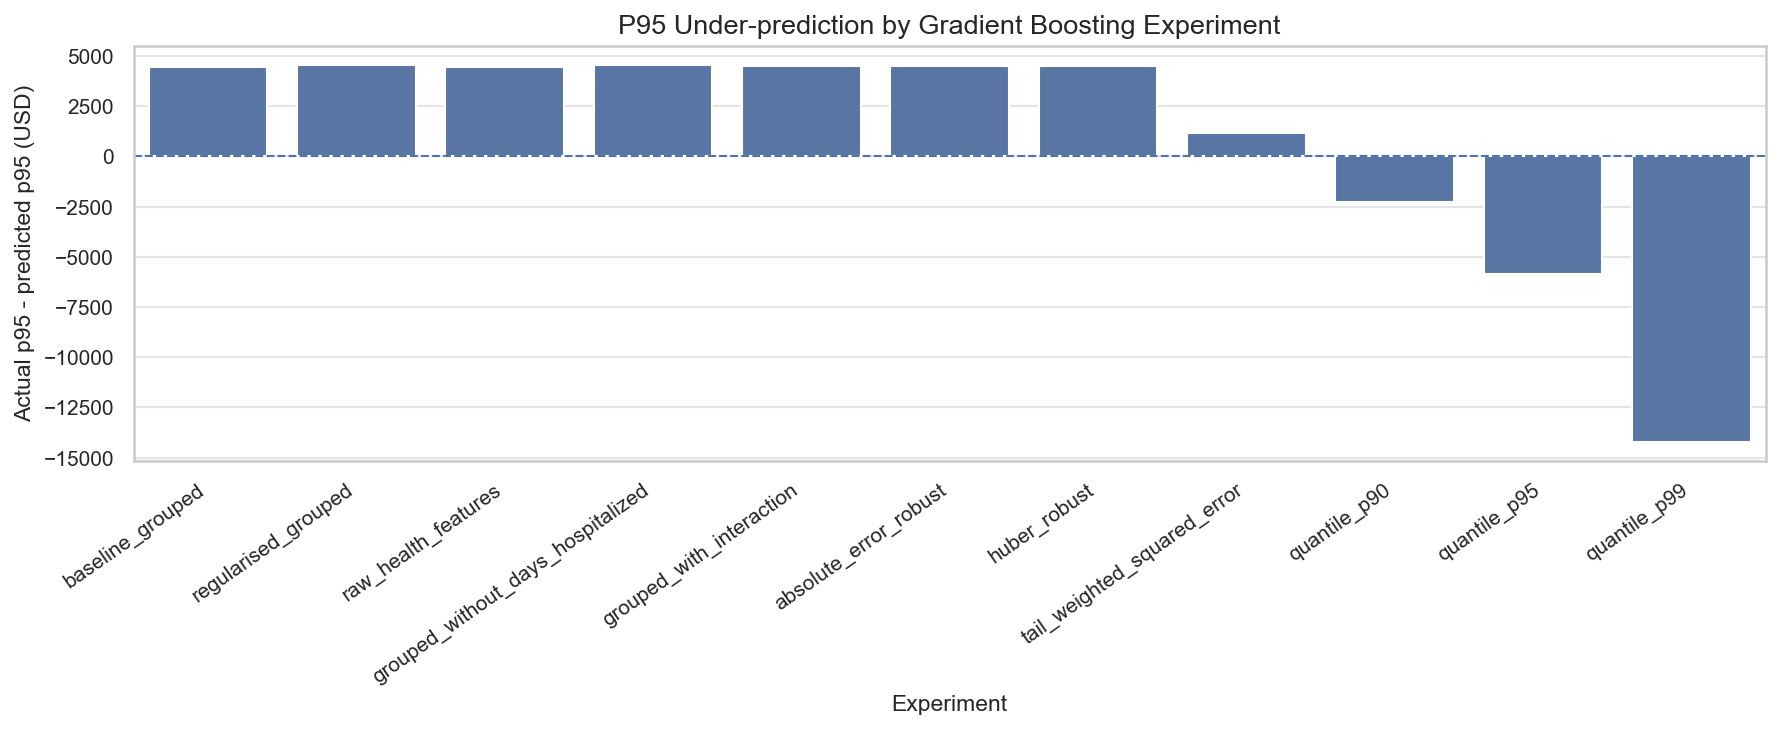

In [16]:
plot_df = comparison_table.copy()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.barplot(
    data=plot_df,
    x="experiment name",
    y="p95 underprediction",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("P95 Under-prediction by Gradient Boosting Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Actual p95 - predicted p95 (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_gb_p95_underprediction_by_experiment",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_gb_p99_underprediction_by_experiment.png


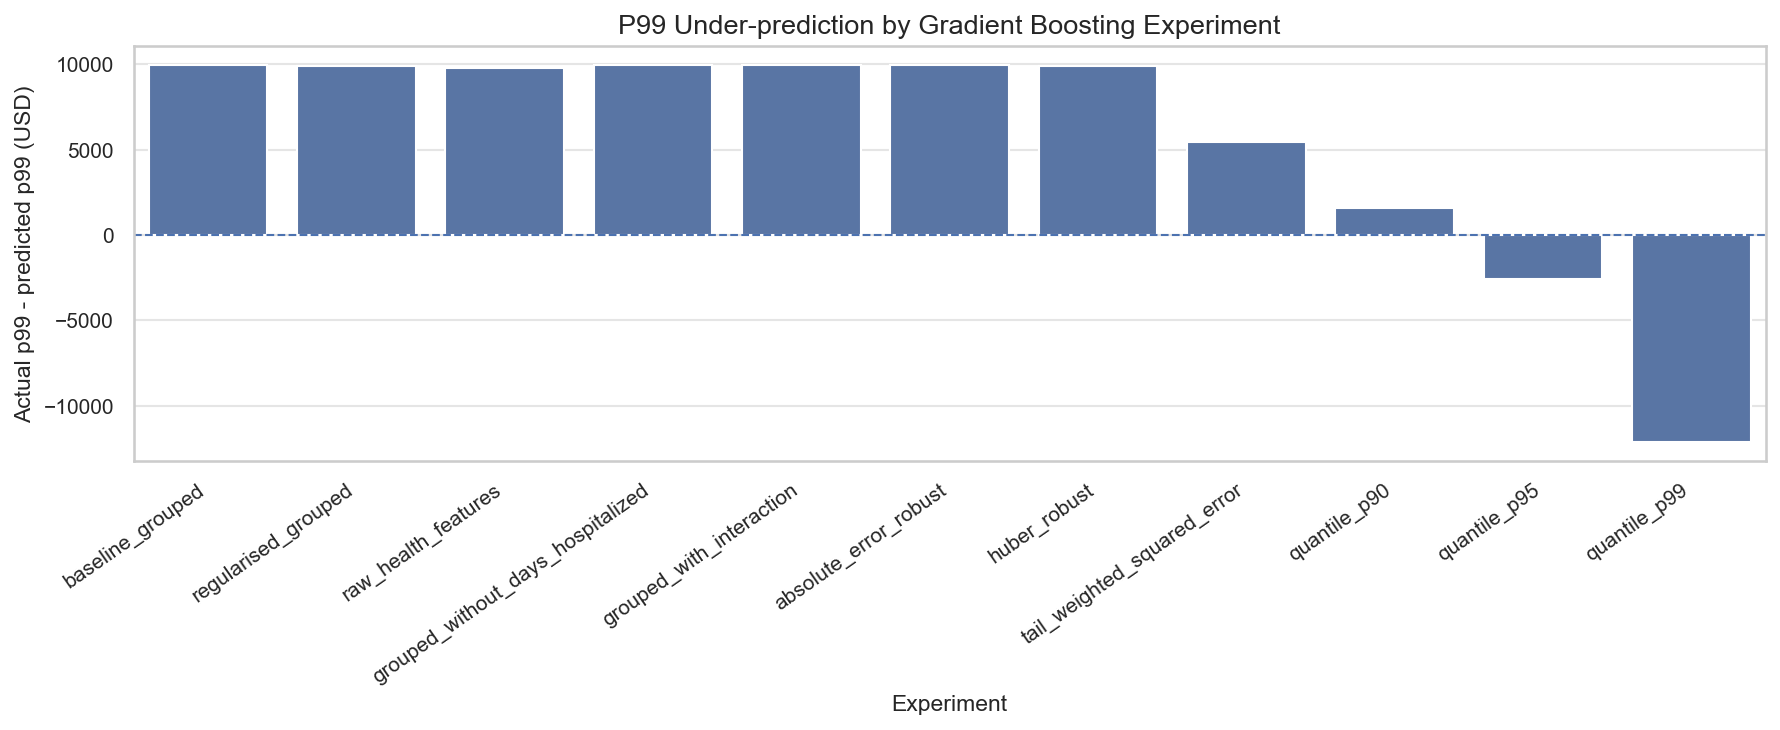

In [17]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.barplot(
    data=plot_df,
    x="experiment name",
    y="p99 underprediction",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("P99 Under-prediction by Gradient Boosting Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("Actual p99 - predicted p99 (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_gb_p99_underprediction_by_experiment",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_gb_rmse_by_experiment.png


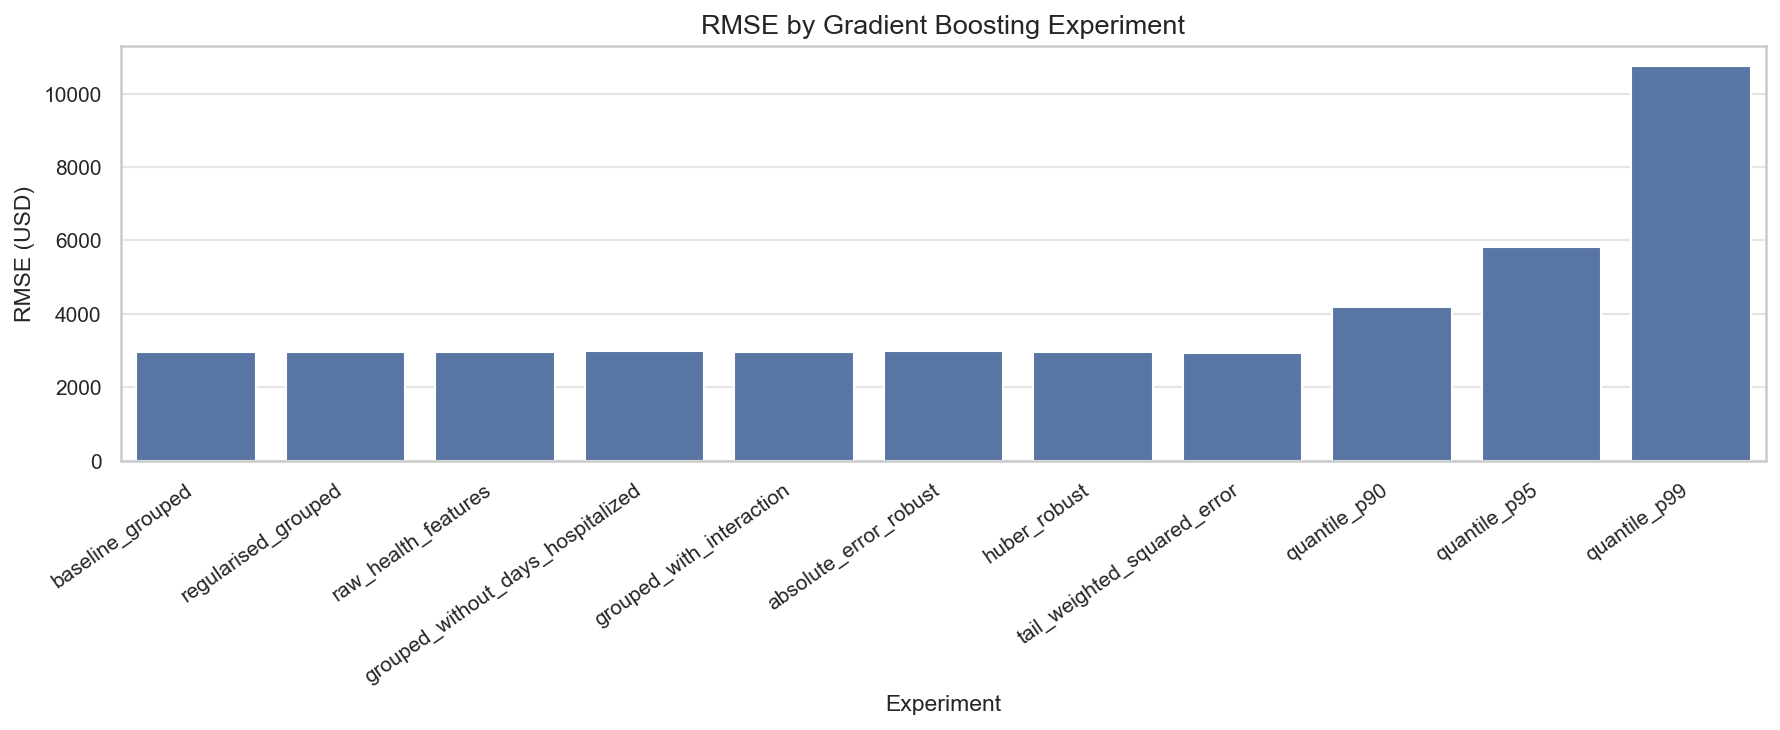

In [18]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.barplot(
    data=plot_df,
    x="experiment name",
    y="RMSE",
    ax=ax,
)

ax.set_title("RMSE by Gradient Boosting Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("RMSE (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_gb_rmse_by_experiment",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_gb_mae_by_experiment.png


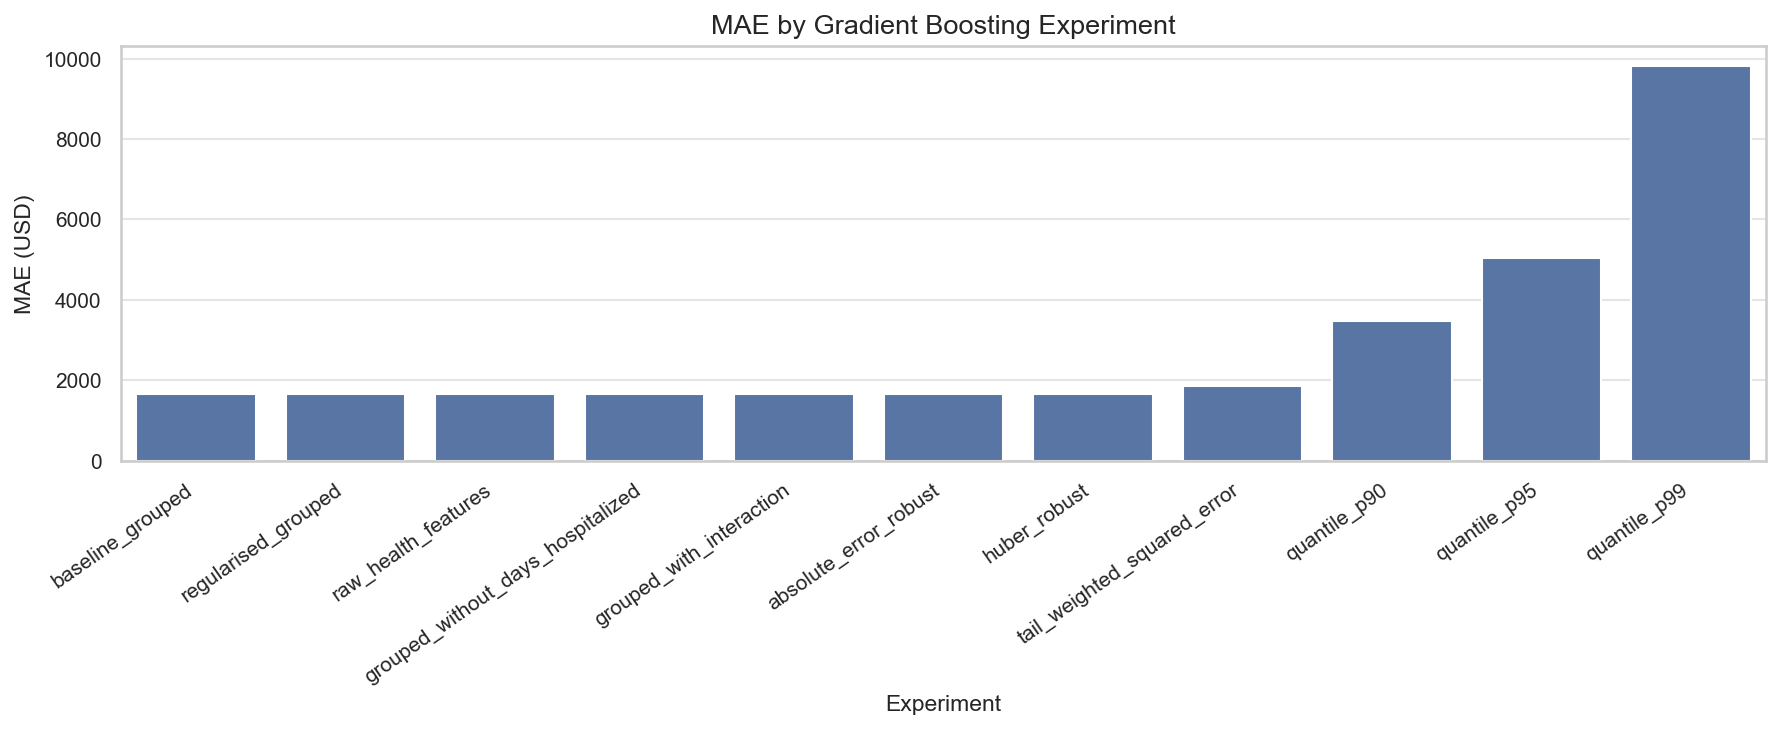

In [19]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

sns.barplot(
    data=plot_df,
    x="experiment name",
    y="MAE",
    ax=ax,
)

ax.set_title("MAE by Gradient Boosting Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("MAE (USD)")

plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_gb_mae_by_experiment",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_gb_quantile_calibration.png


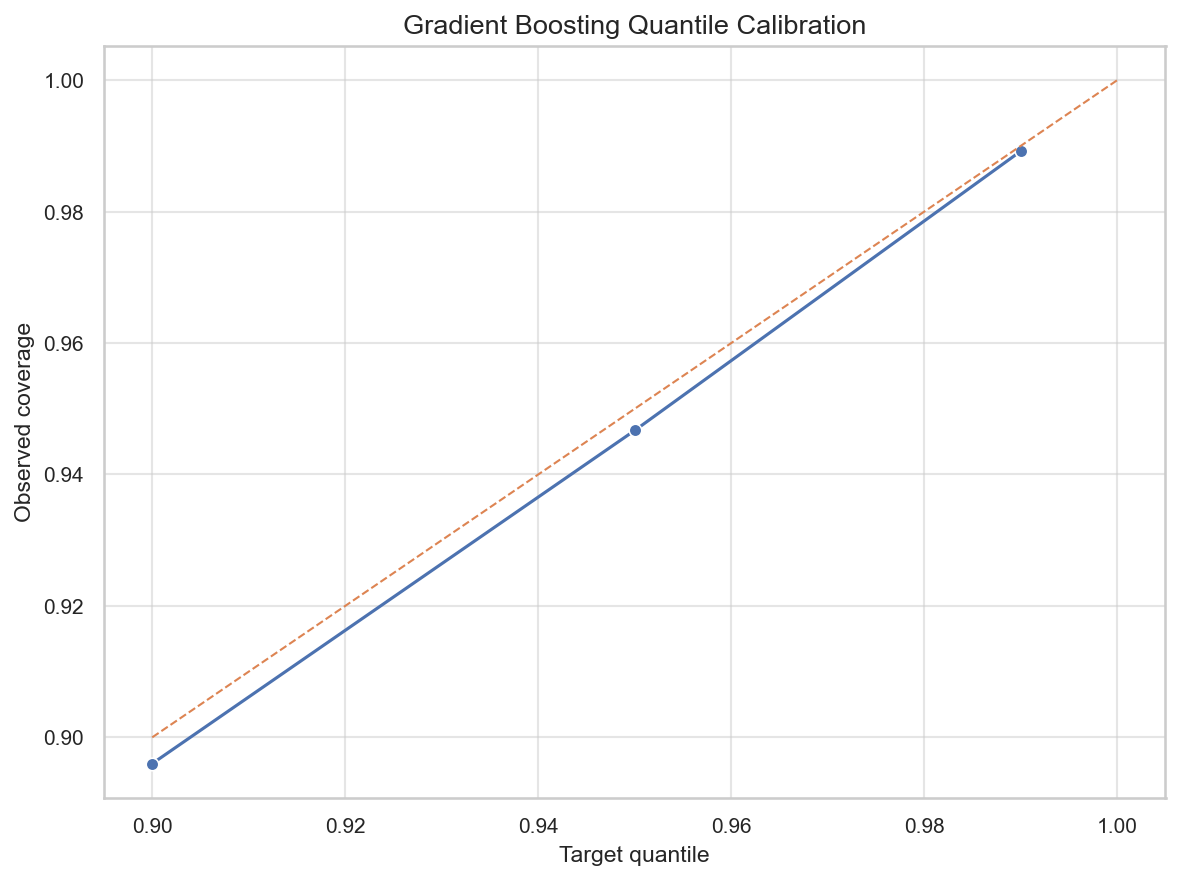

In [20]:
if not quantile_table.empty:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    sns.lineplot(
        data=quantile_table,
        x="quantile alpha",
        y="observed coverage",
        marker="o",
        ax=ax,
    )

    ax.plot(
        [0.90, 1.00],
        [0.90, 1.00],
        linestyle="--",
        linewidth=1,
    )

    ax.set_title("Gradient Boosting Quantile Calibration")
    ax.set_xlabel("Target quantile")
    ax.set_ylabel("Observed coverage")

    fig.tight_layout()

    save_report_figure(
        fig=fig,
        figure_dir=FIGURE_DIR,
        file_stem="fig_06_gb_quantile_calibration",
    )

    plt.show()

In [21]:
selected_mean_experiment = "tail_weighted_squared_error"

selected_mean_result = experiment_models[selected_mean_experiment]
selected_mean_predictions = experiment_predictions[selected_mean_experiment]

selected_mean_evaluation = run_regression_evaluation(
    x_test=selected_mean_result.x_test,
    y_true=selected_mean_result.y_test,
    y_pred=selected_mean_predictions["predicted_cost"].to_numpy(),
    y_true_transformed=np.log1p(selected_mean_result.y_test),
    y_pred_transformed=selected_mean_predictions["predicted_log_cost"].to_numpy(),
    actual_col="actual_cost",
    predicted_col="predicted_cost",
    transformed_actual_col="actual_log_cost",
    transformed_predicted_col="predicted_log_cost",
    group_cols=[
        "hospitalizations_grouped",
        "chronic_count_grouped",
        "days_hospitalized_grouped",
    ],
    original_scale_name="cost",
    transformed_scale_name="log",
)

selected_mean_metrics = selected_mean_evaluation["metrics"]
selected_mean_tail = selected_mean_evaluation["tail_summary"]

display(selected_mean_predictions.head())
display(selected_mean_metrics)
display(selected_mean_tail.round(2))
display(pd.Series(experiment_features[selected_mean_experiment], name="features_used"))

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,predicted_cost,residual,absolute_error,actual_log_cost,predicted_log_cost
75721,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,3,...,1,1,1,4+,1640.86,8152.748612,-6511.888612,6511.888612,7.403585,9.006233
80184,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,0,...,0,0,0,0,2306.61,1672.503742,634.106258,634.106258,7.743968,7.422675
19864,55,Male,East,Urban,226200.0,HS,Married,Employed,3,1,...,0,0,0,0,1015.03,3198.485501,-2183.455501,2183.455501,6.923658,8.070745
76699,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,1,...,0,0,1,0,1136.82,2560.220140,-1423.400140,1423.400140,7.036869,7.848239
92991,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,1,...,0,0,2,0,3990.84,4635.786007,-644.946007,644.946007,8.292008,8.441777


,value
rmse_cost,2937.3652
r2_cost,0.1232
pearson_correlation_cost,0.4156
sdep_cost,2935.2340
bias_cost,-113.7816
mae_cost,1861.5766
mean_actual_cost,3027.7912
mean_predicted_cost,3141.5728
median_actual_cost,2096.4650
median_predicted_cost,2582.3001


,statistic,actual_cost,predicted_cost,difference,relative_difference
0,mean,3027.79,3141.57,-113.78,-0.04
1,p50,2096.46,2582.30,-485.84,-0.23
2,p90,6324.06,5963.55,360.51,0.06
3,p95,8695.57,7516.12,1179.45,0.14
4,p99,15189.61,9735.91,5453.70,0.36
5,max,65724.90,17307.72,48417.18,0.74


0                           age
1                           sex
2                        region
3                   urban_rural
4                        income
5                     education
6                marital_status
7             employment_status
8                household_size
9                    dependents
10                          bmi
11                       smoker
12                 alcohol_freq
13             visits_last_year
14             medication_count
15                  systolic_bp
16                 diastolic_bp
17                          ldl
18                        hba1c
19                    plan_type
20                 network_tier
21                   deductible
22                        copay
23            policy_term_years
24     policy_changes_last_2yrs
25             provider_quality
26                   risk_score
27                 hypertension
28                     diabetes
29                       asthma
30                         copd
31      

In [22]:
selected_mean_features = pd.Series(
    experiment_features[selected_mean_experiment],
    name="Feature",
).to_frame()

selected_mean_summary = pd.DataFrame({
    "Item": [
        "Selected mean-cost experiment",
        "Loss",
        "Tail weighted",
        "Training observations",
        "Test observations",
        "Target transformation",
    ],
    "Value": [
        selected_mean_experiment,
        selected_mean_result.loss,
        True,
        selected_mean_result.x_train.shape[0],
        selected_mean_result.x_test.shape[0],
        selected_mean_result.target_transform,
    ],
})

display(selected_mean_summary)
display(selected_mean_features)

export_report_table(
    table=selected_mean_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_summary",
    caption="Selected mean-cost Gradient Boosting experiment summary.",
    label="tab:06-selected-mean-summary",
    index=False,
)

export_report_table(
    table=selected_mean_metrics,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_metrics",
    caption="Predictive performance of the selected tail-weighted Gradient Boosting model.",
    label="tab:06-selected-mean-metrics",
    index=False,
    float_format="%.4f",
)

export_report_table(
    table=selected_mean_tail.round(2),
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_tail_summary",
    caption="Tail summary for the selected tail-weighted Gradient Boosting model.",
    label="tab:06-selected-mean-tail-summary",
    index=False,
)

export_report_table(
    table=selected_mean_features,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_features",
    caption="Features used by the selected tail-weighted Gradient Boosting model.",
    label="tab:06-selected-mean-features",
    index=False,
)

,Item,Value
0,Selected mean-cost experiment,tail_weighted_squared_error
1,Loss,squared_error
2,Tail weighted,True
3,Training observations,80000
4,Test observations,20000
5,Target transformation,log1p


,Feature
0,age
1,sex
2,region
3,urban_rural
4,income
5,education
6,marital_status
7,employment_status
8,household_size
9,dependents


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_summary.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_predictions.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_metrics.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_metrics.tex
Saved table: C:\Users\maxfa\One

{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_mean_features.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_mean_features.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_mean_actual_vs_predicted_log.png


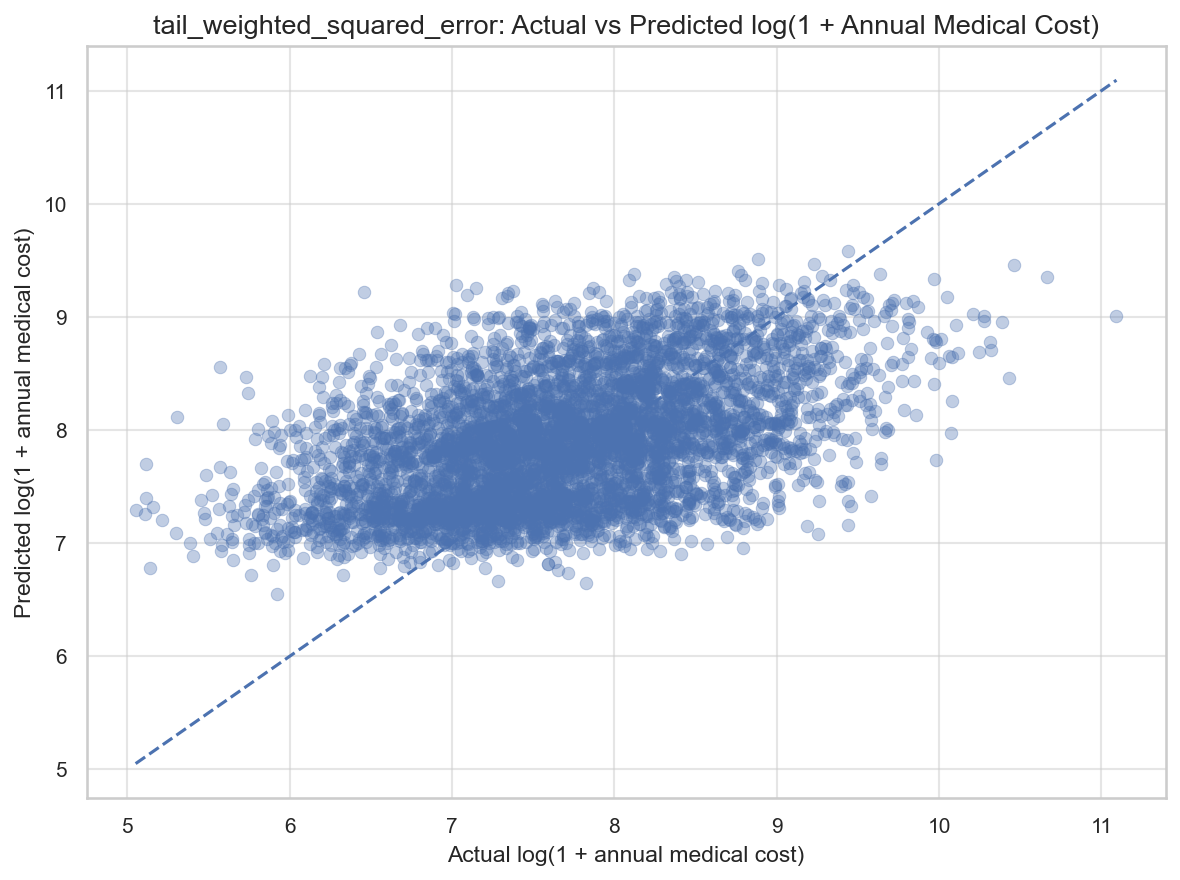

In [23]:
plot_actual_vs_predicted(
    data=selected_mean_predictions,
    actual_col="actual_log_cost",
    predicted_col="predicted_log_cost",
    title=f"{selected_mean_experiment}: Actual vs Predicted log(1 + Annual Medical Cost)",
    xlabel="Actual log(1 + annual medical cost)",
    ylabel="Predicted log(1 + annual medical cost)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_mean_actual_vs_predicted_log",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_mean_residual_distribution.png


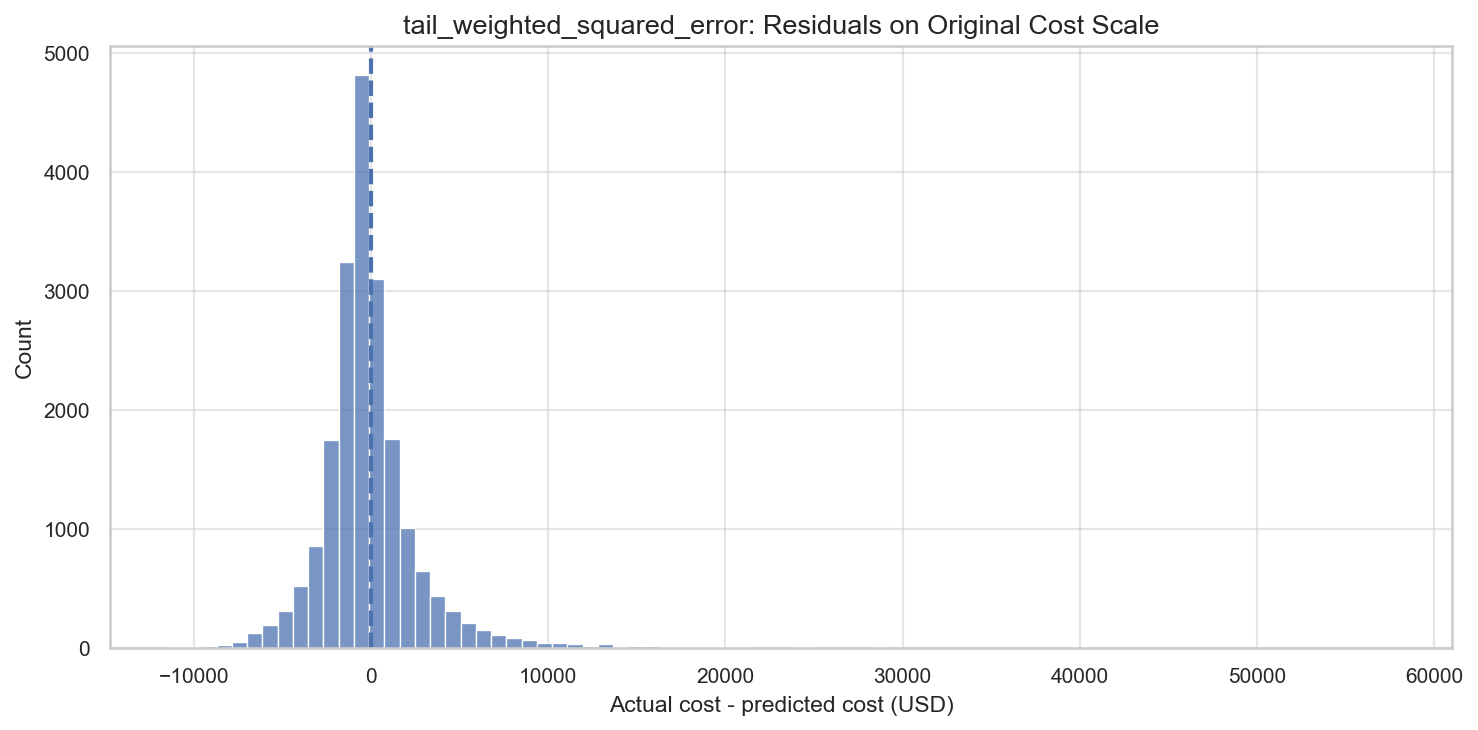

In [24]:
plot_residual_distribution(
    data=selected_mean_predictions,
    residual_col="residual",
    title=f"{selected_mean_experiment}: Residuals on Original Cost Scale",
    xlabel="Actual cost - predicted cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_mean_residual_distribution",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_mean_tail_percentile_comparison.png


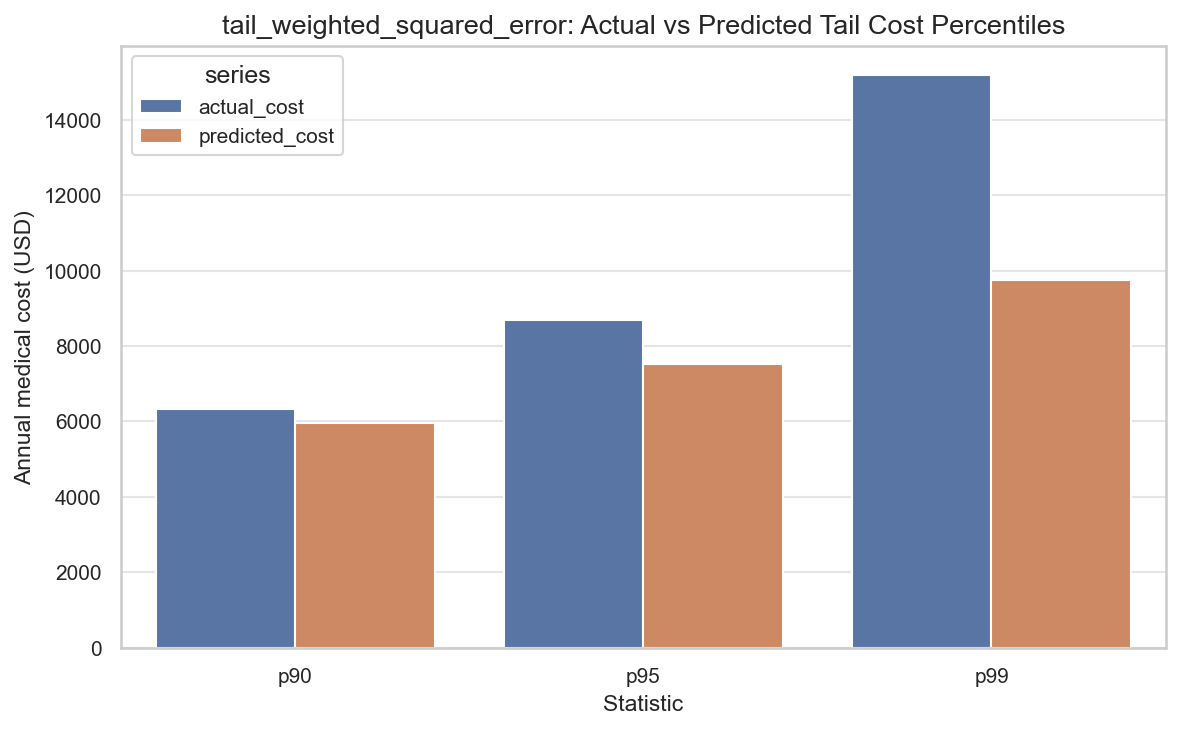

In [25]:
plot_tail_comparison(
    tail_df=selected_mean_tail,
    statistics=("p90", "p95", "p99"),
    actual_col="actual_cost",
    predicted_col="predicted_cost",
    title=f"{selected_mean_experiment}: Actual vs Predicted Tail Cost Percentiles",
    ylabel="Annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_mean_tail_percentile_comparison",
)

plt.show()

In [26]:
hospital_model_summary = selected_mean_evaluation["group_summary_hospitalizations_grouped"]
chronic_model_summary = selected_mean_evaluation["group_summary_chronic_count_grouped"]
days_hospitalized_model_summary = selected_mean_evaluation["group_summary_days_hospitalized_grouped"]

display(hospital_model_summary)
display(chronic_model_summary)
display(days_hospitalized_model_summary)

,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
hospitalizations_grouped,,,,,,,,,,,,,,,
0,18188,2813.47,2828.79,1987.04,2441.86,1693.55,5833.04,4975.51,857.53,7987.55,6111.08,1876.47,13713.35,8743.31,4970.04
1,1742,5042.25,6160.42,3657.32,6299.46,3448.33,10087.07,8987.70,1099.37,13129.64,9919.17,3210.47,23494.29,11555.11,11939.18
2+,70,8582.41,9285.14,4906.64,9533.07,6032.16,18614.89,12209.81,6405.08,28464.62,12566.97,15897.65,37382.90,14405.15,22977.75


,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
chronic_count_grouped,,,,,,,,,,,,,,,
0,9290,2212.49,1943.64,1575.86,1607.43,1256.06,4448.06,2997.61,1450.44,6168.38,4121.29,2047.09,10667.34,6846.21,3821.13
1,7506,3316.46,3545.23,2398.17,3027.85,2049.65,6755.76,5857.10,898.65,9085.72,7254.56,1831.16,14794.49,8775.88,6018.62
2,2644,4442.01,5356.14,3249.29,4729.70,3004.26,8994.36,8478.34,516.02,12169.45,9401.61,2767.84,19870.09,11321.03,8549.06
3,504,5793.30,7023.57,4287.90,6523.34,3893.91,10940.31,10106.96,833.34,16011.83,11413.74,4598.10,24415.33,12999.96,11415.37
4+,56,7927.76,8268.69,6165.62,7681.93,4860.97,16432.71,11675.91,4756.80,19626.42,13819.51,5806.91,22124.42,16094.12,6030.30


,n,actual_mean,predicted_mean,actual_median,predicted_median,mae,actual_p90,predicted_p90,p90_difference,actual_p95,predicted_p95,p95_difference,actual_p99,predicted_p99,p99_difference
days_hospitalized_grouped,,,,,,,,,,,,,,,
0,18188,2813.47,2828.79,1987.04,2441.86,1693.55,5833.04,4975.51,857.53,7987.55,6111.08,1876.47,13713.35,8743.31,4970.04
1-3,745,3934.41,4529.23,2884.85,4090.72,2745.42,7785.04,7528.33,256.71,11561.65,8435.81,3125.83,18065.42,10176.47,7888.95
4+,1067,6048.02,7504.34,4450.08,7454.93,4108.63,11792.20,9758.92,2033.29,15435.36,10799.77,4635.59,29784.17,12565.71,17218.46


In [27]:
export_report_table(
    table=hospital_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_group_summary_hospitalisation",
    caption="Observed and predicted mean annual cost by hospitalisation group for the selected tail-weighted Gradient Boosting model.",
    label="tab:06-selected-mean-group-summary-hospitalisation",
    index=False,
)

export_report_table(
    table=chronic_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_group_summary_chronic_count",
    caption="Observed and predicted mean annual cost by chronic disease count group for the selected tail-weighted Gradient Boosting model.",
    label="tab:06-selected-mean-group-summary-chronic-count",
    index=False,
)

export_report_table(
    table=days_hospitalized_model_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_mean_group_summary_days_hospitalised",
    caption="Observed and predicted mean annual cost by days hospitalised group for the selected tail-weighted Gradient Boosting model.",
    label="tab:06-selected-mean-group-summary-days-hospitalised",
    index=False,
)

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_group_summary_hospitalisation.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_group_summary_hospitalisation.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_group_summary_chronic_count.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_mean_group_summary_chronic_count.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_exp

{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_mean_group_summary_days_hospitalised.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_mean_group_summary_days_hospitalised.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_mean_grouped_hospitalisation_mean_cost.png


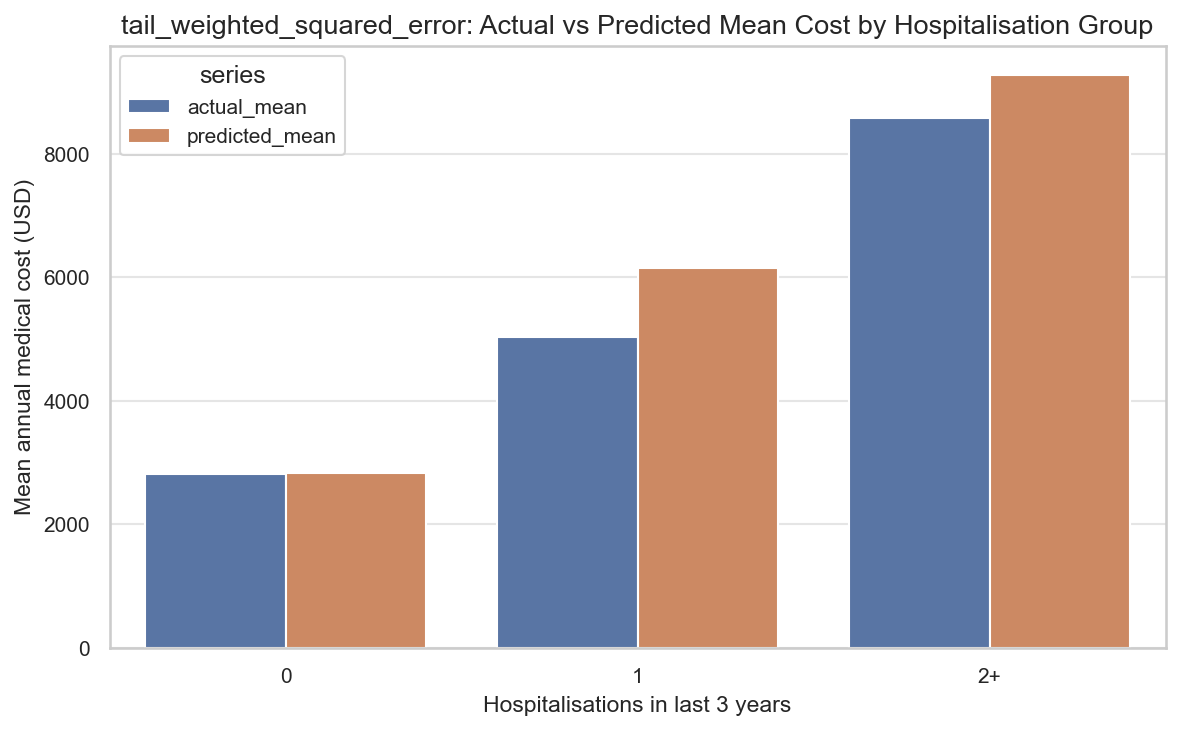

In [28]:
plot_grouped_actual_vs_predicted(
    grouped_summary=hospital_model_summary,
    group_col="hospitalizations_grouped",
    title=f"{selected_mean_experiment}: Actual vs Predicted Mean Cost by Hospitalisation Group",
    xlabel="Hospitalisations in last 3 years",
    ylabel="Mean annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_mean_grouped_hospitalisation_mean_cost",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_mean_grouped_chronic_count_mean_cost.png


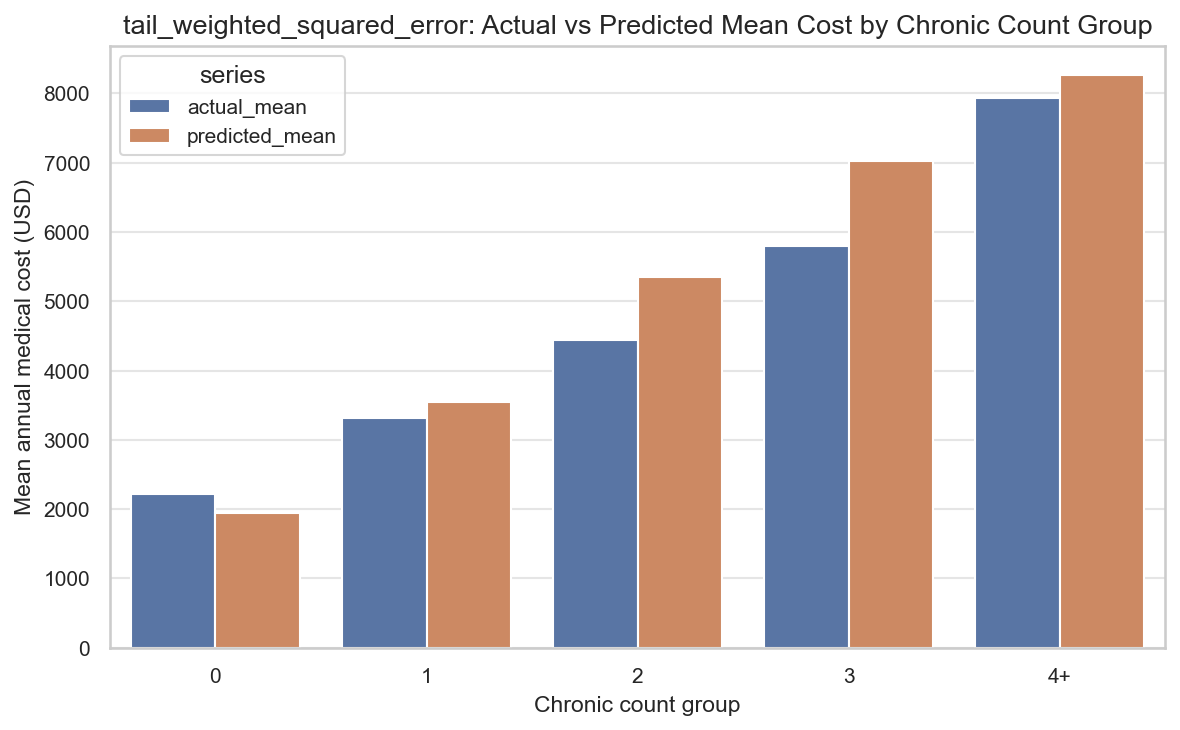

In [29]:
plot_grouped_actual_vs_predicted(
    grouped_summary=chronic_model_summary,
    group_col="chronic_count_grouped",
    title=f"{selected_mean_experiment}: Actual vs Predicted Mean Cost by Chronic Count Group",
    xlabel="Chronic count group",
    ylabel="Mean annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_mean_grouped_chronic_count_mean_cost",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_mean_grouped_days_hospitalised_mean_cost.png


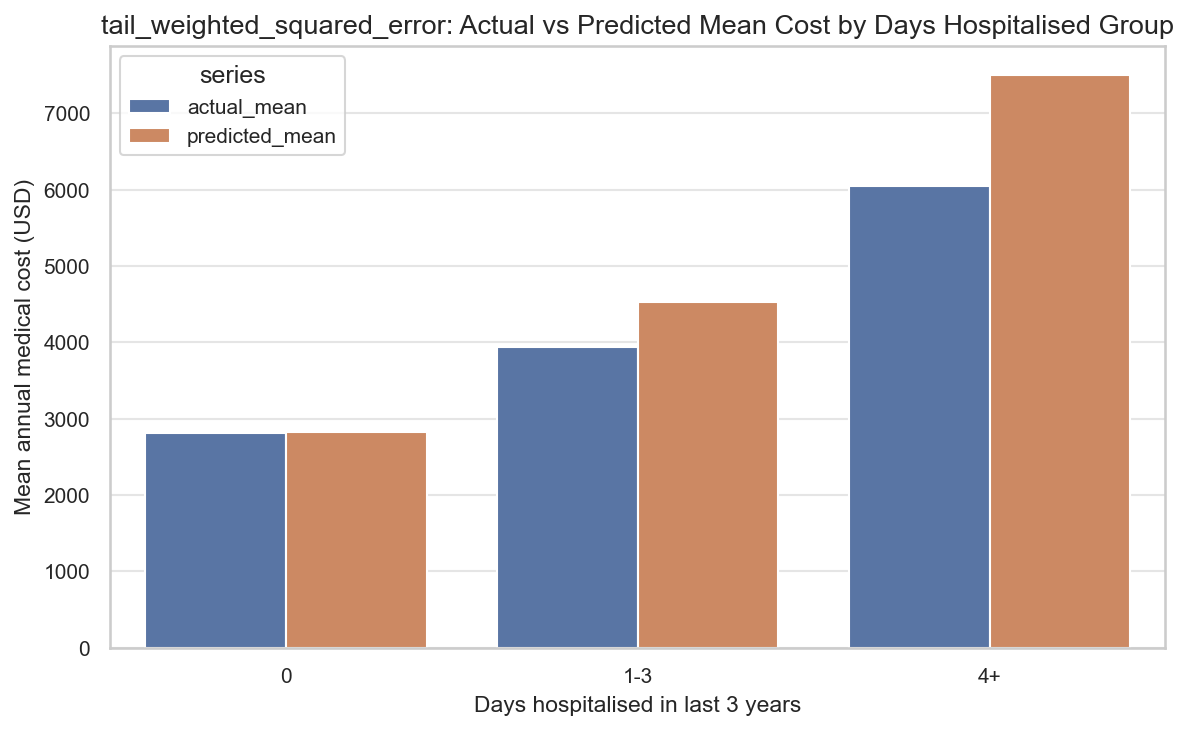

In [30]:
plot_grouped_actual_vs_predicted(
    grouped_summary=days_hospitalized_model_summary,
    group_col="days_hospitalized_grouped",
    title=f"{selected_mean_experiment}: Actual vs Predicted Mean Cost by Days Hospitalised Group",
    xlabel="Days hospitalised in last 3 years",
    ylabel="Mean annual medical cost (USD)",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_mean_grouped_days_hospitalised_mean_cost",
)

plt.show()

In [31]:
selected_tail_experiment = "quantile_p95"

selected_tail_result = experiment_models[selected_tail_experiment]
selected_tail_predictions = experiment_predictions[selected_tail_experiment]

selected_tail_coverage = np.mean(
    selected_tail_predictions["actual_cost"] <= selected_tail_predictions["predicted_cost"]
)

selected_tail_pinball = mean_pinball_loss(
    selected_tail_predictions["actual_cost"],
    selected_tail_predictions["predicted_cost"],
    alpha=float(selected_tail_result.quantile_alpha),
)

print(f"Selected tail experiment: {selected_tail_experiment}")
print(f"Target quantile: {selected_tail_result.quantile_alpha:.2f}")
print(f"Observed coverage: {selected_tail_coverage:.4f}")
print(f"Pinball loss: {selected_tail_pinball:.2f}")

display(selected_tail_predictions.head())

Selected tail experiment: quantile_p95
Target quantile: 0.95
Observed coverage: 0.9467
Pinball loss: 409.04


,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,had_major_procedure,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped,actual_cost,predicted_cost,residual,absolute_error,actual_log_cost,predicted_log_cost
75721,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,3,...,1,1,1,4+,1640.86,15374.087566,-13733.227566,13733.227566,7.403585,9.640504
80184,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,0,...,0,0,0,0,2306.61,5048.640397,-2742.030397,2742.030397,7.743968,8.527072
19864,55,Male,East,Urban,226200.0,HS,Married,Employed,3,1,...,0,0,0,0,1015.03,7935.845148,-6920.815148,6920.815148,6.923658,8.979271
76699,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,1,...,0,0,1,0,1136.82,7473.180969,-6336.360969,6336.360969,7.036869,8.919210
92991,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,1,...,0,0,2,0,3990.84,10171.728126,-6180.888126,6180.888126,8.292008,9.227466


In [32]:
selected_tail_summary = pd.DataFrame({
    "Item": [
        "Selected tail experiment",
        "Target quantile",
        "Observed coverage",
        "Coverage error",
        "Pinball loss",
        "Training observations",
        "Test observations",
        "Target transformation",
    ],
    "Value": [
        selected_tail_experiment,
        selected_tail_result.quantile_alpha,
        selected_tail_coverage,
        selected_tail_coverage - float(selected_tail_result.quantile_alpha),
        selected_tail_pinball,
        selected_tail_result.x_train.shape[0],
        selected_tail_result.x_test.shape[0],
        selected_tail_result.target_transform,
    ],
})

display(selected_tail_summary)

export_report_table(
    table=selected_tail_summary,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_tail_summary",
    caption="Selected Quantile Gradient Boosting model summary.",
    label="tab:06-selected-tail-summary",
    index=False,
    float_format="%.4f",
)

,Item,Value
0,Selected tail experiment,quantile_p95
1,Target quantile,0.95
2,Observed coverage,0.9467
3,Coverage error,-0.0033
4,Pinball loss,409.037827
5,Training observations,80000
6,Test observations,20000
7,Target transformation,log1p


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_summary.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_predictions.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_tail_predictions.csv')

In [33]:
importance_df = get_feature_importances(selected_tail_result)

display(importance_df.head(30))

,feature,importance
0,risk_score,0.360233
1,days_hospitalized_grouped_4+,0.107363
2,chronic_count_grouped_0,0.086202
3,days_hospitalized_grouped_0,0.066930
4,smoker_Never,0.045962
5,visits_last_year,0.045551
6,hospitalizations_grouped_0,0.036967
7,income,0.027003
8,chronic_count_grouped_1,0.022873
9,smoker_Current,0.022472


In [34]:
selected_tail_feature_importance_export = importance_df.head(30).copy()

display(selected_tail_feature_importance_export)

export_report_table(
    table=selected_tail_feature_importance_export,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_tail_feature_importance",
    caption="Top feature importance values for the selected Quantile Gradient Boosting model.",
    label="tab:06-selected-tail-feature-importance",
    index=False,
    float_format="%.4f",
)

,feature,importance
0,risk_score,0.360233
1,days_hospitalized_grouped_4+,0.107363
2,chronic_count_grouped_0,0.086202
3,days_hospitalized_grouped_0,0.066930
4,smoker_Never,0.045962
5,visits_last_year,0.045551
6,hospitalizations_grouped_0,0.036967
7,income,0.027003
8,chronic_count_grouped_1,0.022873
9,smoker_Current,0.022472


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_feature_importance.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_feature_importance.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_all_feature_importance.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_tail_all_feature_importance.csv')

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_tail_feature_importance.png


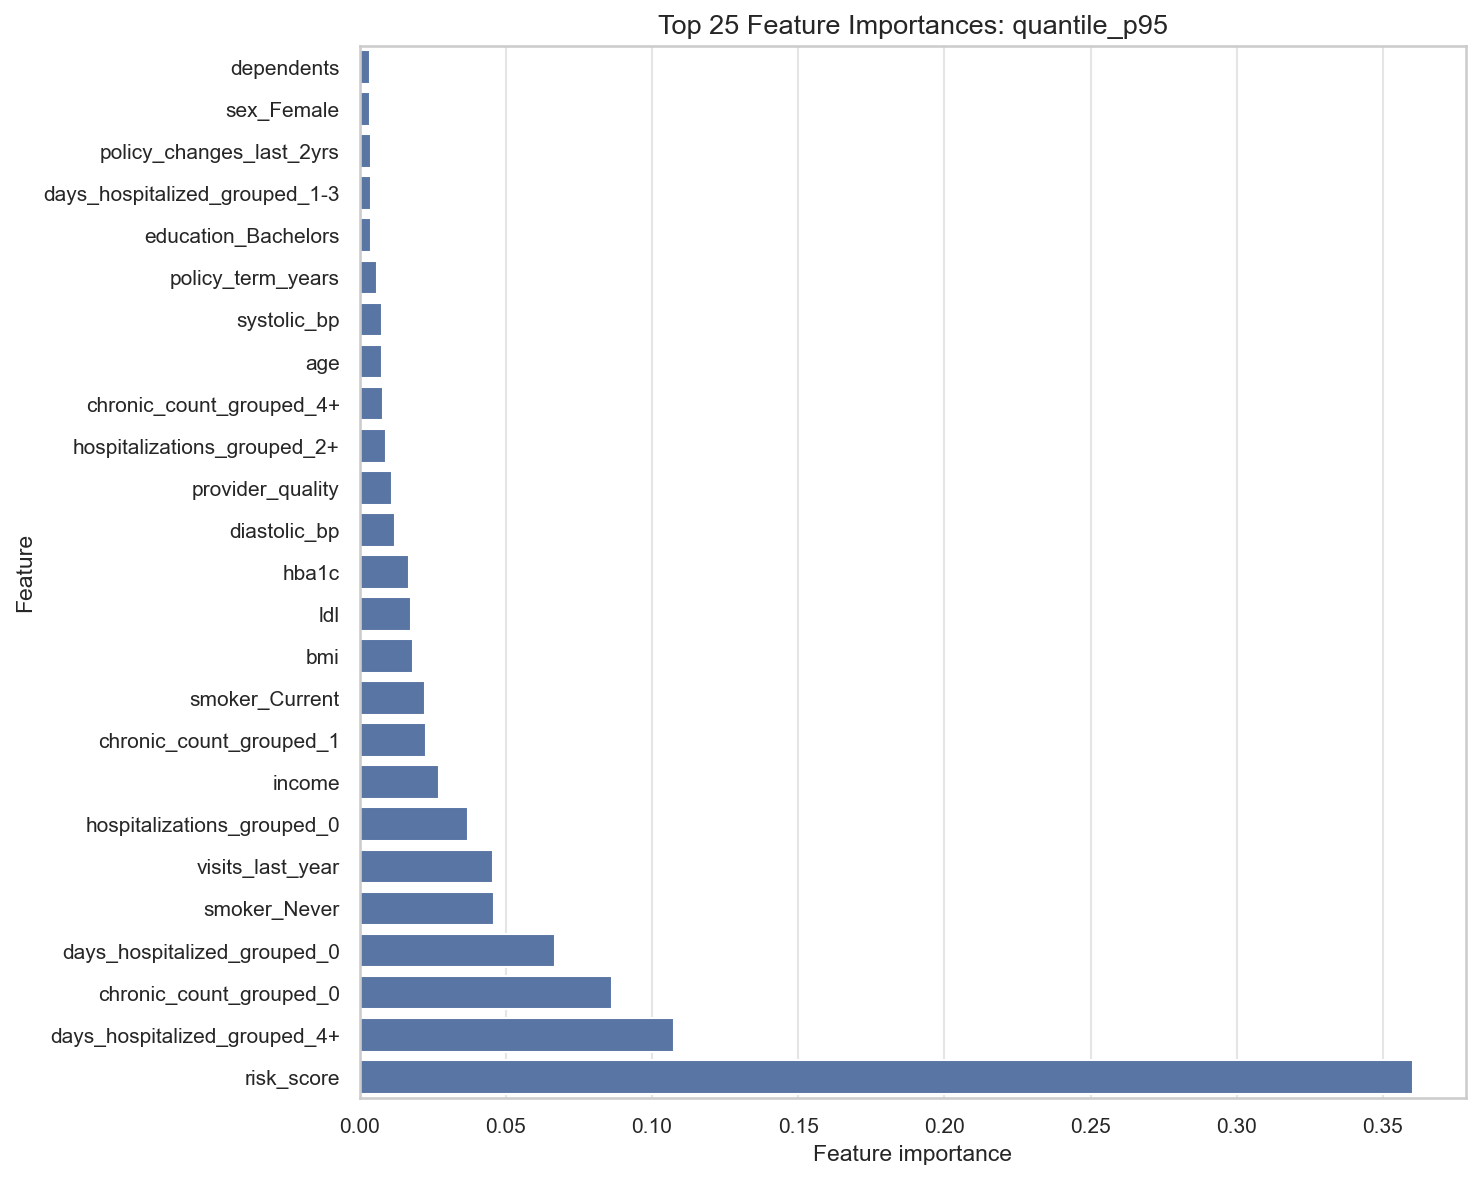

In [35]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

top_importance = importance_df.head(25).sort_values("importance")

sns.barplot(
    data=top_importance,
    x="importance",
    y="feature",
    ax=ax,
)

ax.set_title(f"Top 25 Feature Importances: {selected_tail_experiment}")
ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_tail_feature_importance",
)

plt.show()

In [36]:
shap_result = run_shap_analysis(
    model=selected_tail_result.model,
    x_background=selected_tail_result.x_train,
    x_explain=selected_tail_result.x_test,
    model_type="tree",
    use_transformed_features=True,
    background_size=500,
    explain_size=2000,
    masker_max_samples=500,
    random_state=42,
)

display(shap_result.importance_df.head(30))

,feature,mean_abs_shap,mean_shap
0,risk_score,0.161600,0.005335
1,chronic_count_grouped_0,0.131415,0.002081
2,smoker_Never,0.063276,-0.002393
3,visits_last_year,0.047068,-0.000667
4,days_hospitalized_grouped_0,0.037622,0.001528
5,days_hospitalized_grouped_4+,0.035030,0.002199
6,bmi,0.030738,-0.000380
7,chronic_count_grouped_1,0.025262,0.009548
8,hospitalizations_grouped_0,0.021205,0.000207
9,smoker_Current,0.019552,0.000626


In [37]:
selected_tail_shap_importance_export = shap_result.importance_df.head(30).copy()

display(selected_tail_shap_importance_export)

export_report_table(
    table=selected_tail_shap_importance_export,
    table_dir=TABLE_DIR,
    file_stem="tab_06_selected_tail_shap_importance",
    caption="Top SHAP feature importance values for the selected Quantile Gradient Boosting model.",
    label="tab:06-selected-tail-shap-importance",
    index=False,
    float_format="%.4f",
)

,feature,mean_abs_shap,mean_shap
0,risk_score,0.161600,0.005335
1,chronic_count_grouped_0,0.131415,0.002081
2,smoker_Never,0.063276,-0.002393
3,visits_last_year,0.047068,-0.000667
4,days_hospitalized_grouped_0,0.037622,0.001528
5,days_hospitalized_grouped_4+,0.035030,0.002199
6,bmi,0.030738,-0.000380
7,chronic_count_grouped_1,0.025262,0.009548
8,hospitalizations_grouped_0,0.021205,0.000207
9,smoker_Current,0.019552,0.000626


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_shap_importance.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_shap_importance.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Tables\tab_06_selected_tail_all_shap_importance.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/06_gradient_boosting_experiments/Tables/tab_06_selected_tail_all_shap_importance.csv')

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_tail_shap_bar.png


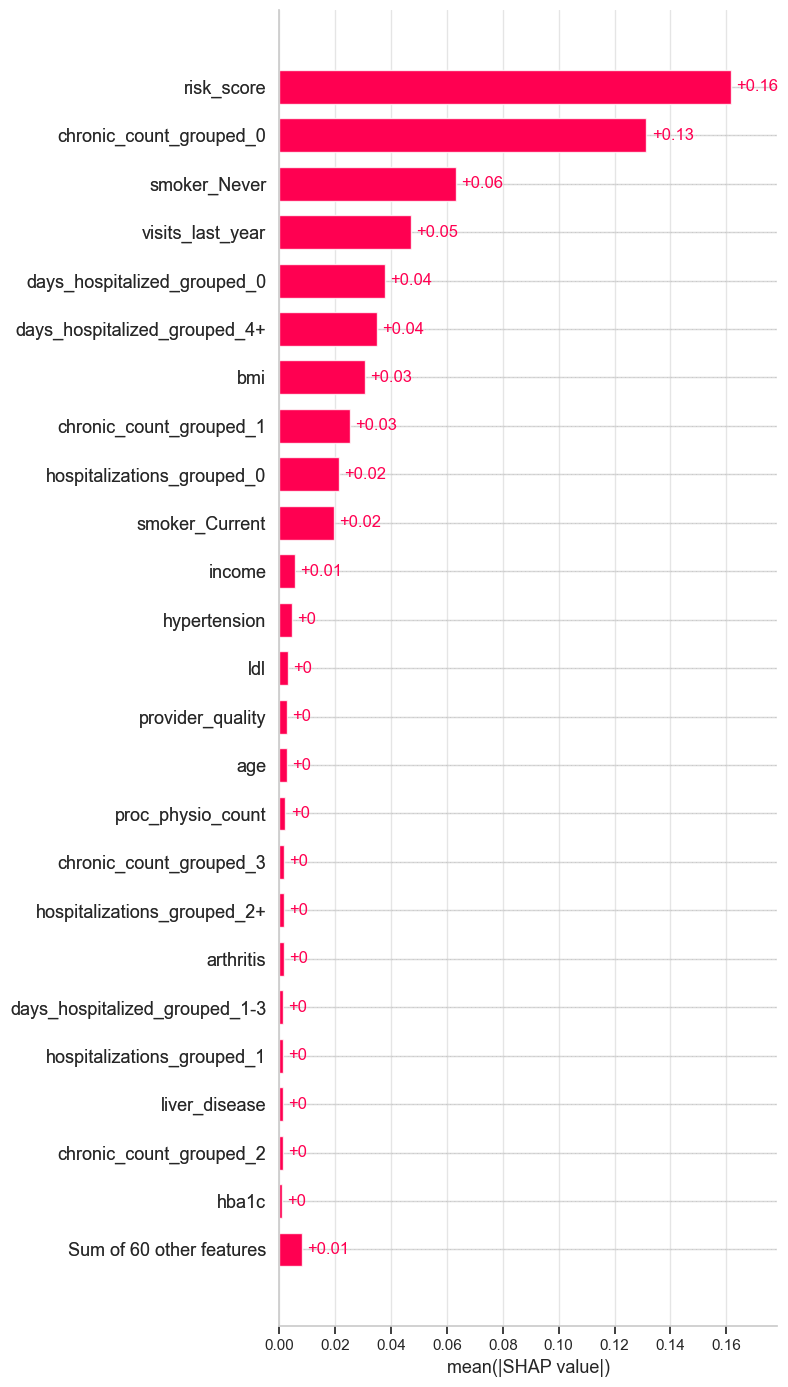

In [38]:
fig = plot_shap_bar(
    shap_result,
    max_display=25,
    show=False,
)

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_tail_shap_bar",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_tail_shap_beeswarm.png


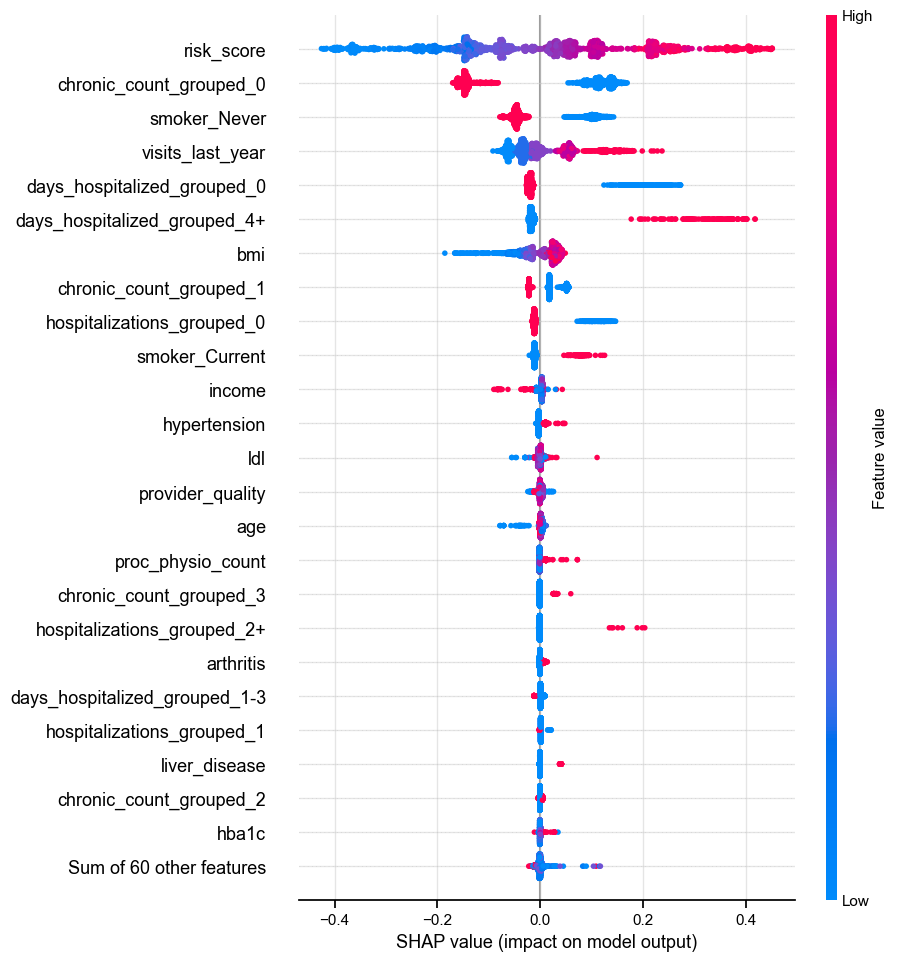

In [39]:
plot_shap_beeswarm(
    shap_result,
    max_display=25,
    text_colour="#000000",
)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_tail_shap_beeswarm",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_tail_shap_importance_dataframe.png


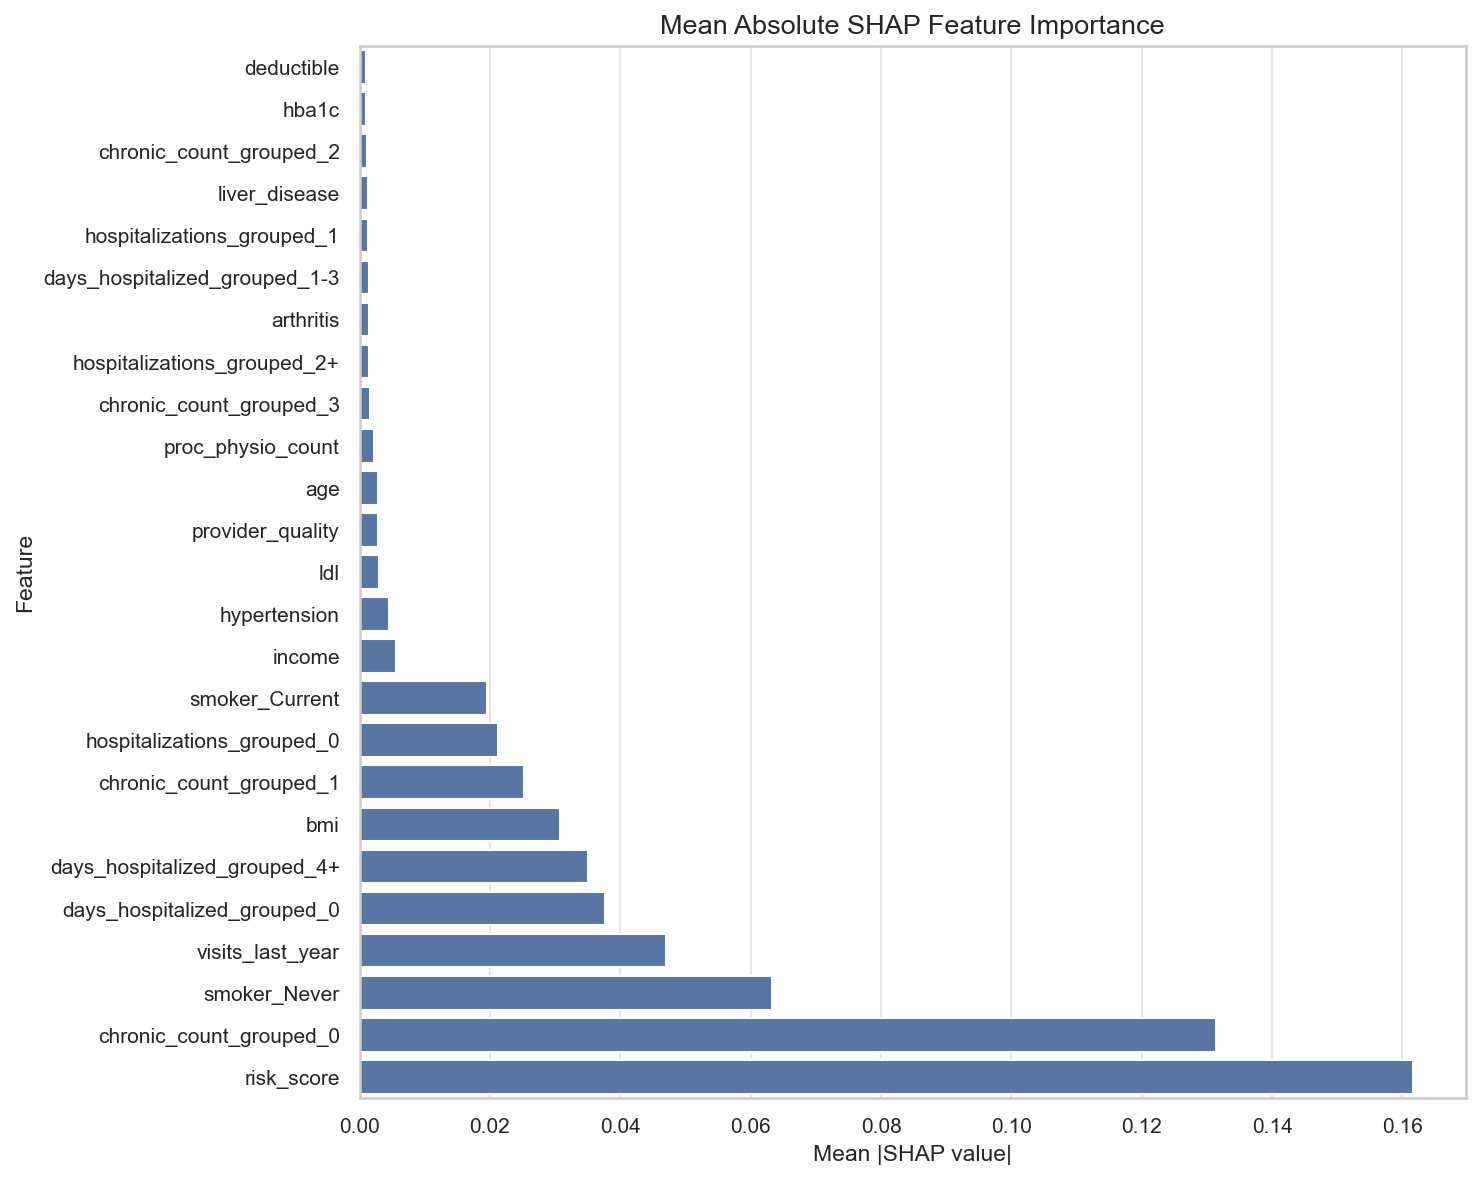

In [40]:
plot_shap_importance_dataframe(shap_result, max_display=25)

fig = plt.gcf()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_tail_shap_importance_dataframe",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\06_gradient_boosting_experiments\Figures\fig_06_selected_tail_shap_waterfall_row_0.png


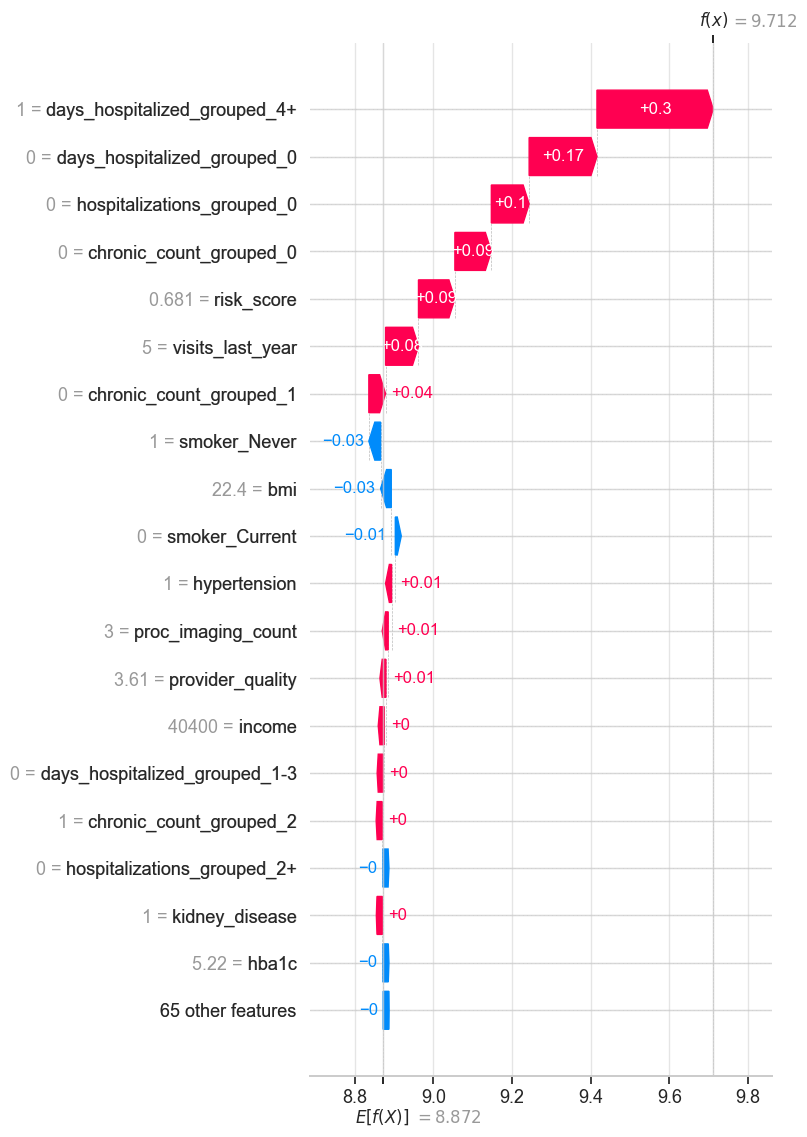

In [41]:
fig = plot_shap_waterfall(
    shap_result,
    row_number=0,
    max_display=20,
    show=False,
)

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_06_selected_tail_shap_waterfall_row_0",
)

plt.show()